### Pre-em


In [1]:
# tabular_030226

# ================
# imports
# ================

import json
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

# ====================
#load data
# ====================
data_root="Module2/dataset" #make sure it the smaller dataset e.g.miniaireadidatset/dataset

# ===================
#read specific columns which are most important and clean/preprocess/create inputs
# ====================


In [2]:
data_root = "dataset"

### Cleaning


In [3]:
# =========================
# 1) Participants base table (participants)
# =========================
p_participants = os.path.join(data_root, "participants.tsv")
participants = pd.read_csv(p_participants, sep="\t")


# Keep only what you need + rename into your preferred names
participants = participants[[
    "participant_id",
    "study_group",
    "recommended_split",
    "age",

]].copy()

participants = participants.rename(columns={
    "recommended_split": "Study Split",
    "age": "Age",
    "study_group": "Study Group"
})

df = participants.copy()

#if missing age use median of column
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"] = df["Age"].fillna(df["Age"].median())

#turn study group into one hot encoding
# healthy
# pre_diabetes_lifestyle_controlled
# oral_medication_and_or_non_insulin_injectable_medication_controlled
# insulin_dependent
study_group_ohe = pd.get_dummies(
    df["Study Group"],
    prefix="study_group"
)

#one hot encoder
df = df.drop(columns=["Study Group"]).join(study_group_ohe)

# turn recommended split into one hot encoding
split_ohe = pd.get_dummies(
    df["Study Split"],
    prefix="split"
)

df = df.drop(columns=["Study Split"]).join(split_ohe)

# This is the master index
master = df.copy()


In [4]:
# =========================
# 2) Wearable activity (wam)
# =========================
p_wam = os.path.join(data_root, "wearable_activity_monitor", "manifest.tsv")
wam = pd.read_csv(p_wam, sep="\t")

# Column names vary
col_hr      = "average_heartrate_bpm"                 # heart rate pulse
col_oxy     = "average_oxygen_saturation_pct"         # oxygen saturation
col_pa      = "average_daily_activity"                # physical activity (note the spaces)
col_sleep   = "average_sleep_hours"                   # sleep
col_stress  = "average_stress_level"                 # stress
col_respire = "average_respiratory_rate_bpm"          # respiratory rate


keep_cols = ["participant_id"]
for c in [col_hr, col_oxy, col_pa, col_sleep, col_stress, col_respire]:
    if c in wam.columns:
        keep_cols.append(c)


wam_sub = wam[keep_cols].copy()

# Rename into the "Variable" names you were using
rename_map = {}
if col_hr in wam_sub.columns:      rename_map[col_hr] = "Heart Rate Pulse"
if col_oxy in wam_sub.columns:     rename_map[col_oxy] = "Oxygen Saturation"
if col_pa in wam_sub.columns:      rename_map[col_pa] = "Physical Activity"
if col_sleep in wam_sub.columns:   rename_map[col_sleep] = "Sleep"
if col_stress in wam_sub.columns:  rename_map[col_stress] = "Stress"
if col_respire in wam_sub.columns: rename_map[col_respire] = "Respiratory Rate"


wam_sub = wam_sub.rename(columns=rename_map)


#if none for col_hr, col_oxy, col_pa, col_sleep, col_stress use median of column
for col in ["Heart Rate Pulse", "Oxygen Saturation", "Physical Activity", "Sleep", "Stress"]:
    if col in wam_sub.columns:
        wam_sub[col] = pd.to_numeric(wam_sub[col], errors="coerce")
        wam_sub[col] = wam_sub[col].fillna(wam_sub[col].median())

#if col_respire normalise
if "Respiratory Rate" in wam_sub.columns:
    wam_sub["Respiratory Rate"] = pd.to_numeric(wam_sub["Respiratory Rate"], errors="coerce")
    x = wam_sub["Respiratory Rate"]
    denom = (x.max() - x.min())
    if pd.notna(denom) and denom != 0:
        wam_sub["Respiratory Rate"] = (x - x.min()) / denom

master = master.merge(wam_sub, on="participant_id", how="left")


In [5]:
# ================================
# 3) Wearable blood glucose (blood glucose)
# =================================
bloodglucose_path = os.path.join(data_root, "wearable_blood_glucose", "manifest.tsv")
bg = pd.read_csv(bloodglucose_path, sep="\t")

blood_glucose = "average_glucose_level_mg_dl" #blood glucose

keep_cols = ["participant_id"]
if blood_glucose in bg.columns:
    keep_cols.append(blood_glucose)

blood_glucose_p = bg[keep_cols].copy()

# Rename into the name
rename_map = {}
if blood_glucose in blood_glucose_p.columns:
    rename_map[blood_glucose] = "Blood Glucose"
blood_glucose_p = blood_glucose_p.rename(columns=rename_map)


#if missing use media
if "Blood Glucose" in blood_glucose_p.columns:
    blood_glucose_p["Blood Glucose"] = pd.to_numeric(blood_glucose_p["Blood Glucose"], errors="coerce")
    blood_glucose_p["Blood Glucose"] = blood_glucose_p["Blood Glucose"].fillna(
        blood_glucose_p["Blood Glucose"].median()
    )


master = master.merge(blood_glucose_p, on="participant_id", how="left")


In [6]:
# =========================
# 4) Cardiac ECG (ecg) -
# =========================
ecg_path = os.path.join(data_root, "cardiac_ecg", "manifest.tsv",)
ecg = pd.read_csv(ecg_path, sep="\t")

ecg_pr = "PR" #Cardiac ECG PR

keep_cols = ["participant_id"]
if ecg_pr in ecg.columns:
    keep_cols.append(ecg_pr)

ecg_p = ecg[keep_cols].copy()

rename_map = {}
if ecg_pr in ecg_p.columns:
    rename_map[ecg_pr] = "PR Interval"

ecg_p = ecg_p.rename(columns=rename_map)

#if missing use median
if "PR Interval" in ecg_p.columns:
    ecg_p["PR Interval"] = pd.to_numeric(ecg_p["PR Interval"], errors="coerce")
    ecg_p["PR Interval"] = ecg_p["PR Interval"].fillna(ecg_p["PR Interval"].median())

master = master.merge(ecg_p, on="participant_id", how="left")

In [7]:
# 5) Condition (condition_occurence) -
# =========================
from sklearn.preprocessing import LabelEncoder

condition_path = os.path.join(data_root, "clinical_data", "condition_occurrence.csv")
cond = pd.read_csv(condition_path)

condition_read = "condition_source_value" #condition_source_value
id_col = "person_id"

cond = cond[[id_col, condition_read]].copy()

#need to clean so gets label encoding/ gets rid of everything before comma e.g. mhoccur_rnl,Kidney problems -> Kidney Problems
cond["Condition_clean"] = (
    cond[condition_read]
    .astype(str)
    .str.split(",", n=1)
    .str[-1]
    .str.strip()
    .str.title()
)

# Drop missing/empty conditions (optional but usually sensible)
cond = cond[cond["Condition_clean"].notna() & (cond["Condition_clean"] != "")]

# (Optional) Deduplicate repeated condition entries per person
cond = cond.drop_duplicates(subset=[id_col, "Condition_clean"])

#Multi-hot encode: one column per condition
cond_ohe = pd.get_dummies(cond["Condition_clean"], prefix="cond")

cond_multi = pd.concat([cond[[id_col]].reset_index(drop=True), cond_ohe.reset_index(drop=True)], axis=1)

# Aggregate to one row per person (max turns any repeated 1s into 1)
cond_multi = cond_multi.groupby(id_col, as_index=False).max()

# Rename condition columns to remove "cond_" prefix
new_cols = {}

for c in cond_multi.columns:
    if c.startswith("cond_"):
        new_name = c.replace("cond_", "")
        new_cols[c] = new_name

cond_multi = cond_multi.rename(columns=new_cols)


# Merge into master
master = master.merge(cond_multi, left_on="participant_id", right_on=id_col, how="left").drop(columns=[id_col])

# After merge, participants with no condition rows will have NaNs in the new cond_* columns
# Convert those NaNs to 0s (recommended for ML)
cond_cols = list(new_cols.values())
master[cond_cols] = master[cond_cols].fillna(0).astype(int)




In [8]:
# =========================
# 6) Measurement
# =========================
p_measurement= os.path.join(data_root, "clinical_data", "measurement.csv")
measurement=pd.read_csv(p_measurement)

#Uses only column called measurement_source_value
person_col="person_id"
type_col="measurement_source_value"
value_col="value_as_number"

measurement=measurement[[person_col, type_col, value_col]].copy()

measurement[value_col]=pd.to_numeric(measurement[value_col],errors="coerce")


#Looks into HB1ac, Red Blood Cell, White Blood Cell, BMI, Glucose, Height, Cholesterol, Insulin
targets = {
    "HbA1c": ["hba1c"],          # output column name "HbA1c"
    "RBC": ["red blood cells", "rbc"],
    "WBC": ["white blood cells", "wbc"],
    "BMI": ["bmi"],
    "Glucose": ["glucose"],
    "Height": ["height"],
    "Cholesterol": ["cholesterol"],
    "Insulin": ["insulin"],
}


# Create Variable column
measurement["Variable"] = pd.NA
src = measurement[type_col].astype(str).str.lower()


for var, keys in targets.items():
    mask = False
    for k in keys:
        mask |= src.str.contains(k, na=False, regex=False)
    measurement.loc[mask, "Variable"] = var

meas = measurement.dropna(subset=["Variable"])

#Gets values from the corresponding columns that variables- HB1ac, Red Blood Cell, White Blood Cell, BMI, Glucose, Height, Cholesterol, Insulin exist
meas_agg = (
    meas
    .groupby([person_col, "Variable"], as_index=False)[value_col]
    .median()
)

meas_wide = (
    meas_agg
    .pivot(index=person_col, columns="Variable", values=value_col)
    .reset_index()
)

# If invalid use median of column for that specific variable

for var in targets.keys():
    if var in meas_wide.columns:
        meas_wide[var] = meas_wide[var].fillna(meas_wide[var].median())

# Save values into master e.g. participant 1068, HB1ac= 6 e.g. one column for each corresponding variable
master = (
    master
    .merge(meas_wide, left_on="participant_id", right_on=person_col, how="left")
    .drop(columns=[person_col])
)

In [9]:
# =========================
# Done: master dataframe (one row per participant)
# =========================
print("Final shape:", master.shape)
print(master.columns.tolist())
master.head()

###########################################################################################################################


Final shape: (1077, 56)
['participant_id', 'Age', 'study_group_healthy', 'study_group_insulin_dependent', 'study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled', 'study_group_pre_diabetes_lifestyle_controlled', 'split_test', 'split_train', 'split_val', 'Heart Rate Pulse', 'Oxygen Saturation', 'Physical Activity', 'Sleep', 'Stress', 'Respiratory Rate', 'Blood Glucose', 'PR Interval', 'Age-Related Macular Degeneration (Am', 'Arthritis (Joint Pain)', 'Cancer (Any Type)', 'Cataracts (In One Or Both Eyes)', 'Chronic Pulmonary (Lung) Problems (E', 'Circulation Problems (Examples: Art', "Dementia (Examples: Alzheimer'S Disea", 'Diabetic Retinopathy (In One Or Both', 'Digestive Problems (Examples: Stomach', 'Do You Use Marijuana Now?', 'Dry Eye (In One Or Both Eyes)', 'Elevated A1C Levels (Elevated Blood Sugar', 'Glaucoma (In One Or Both Eyes)', 'Hearing Impairment', 'Heart Attack', 'High Blood Cholesterol', 'High Blood Pressure', 'Kidney Problems', 'Low Blood Pressu

,participant_id,Age,study_group_healthy,study_group_insulin_dependent,study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled,study_group_pre_diabetes_lifestyle_controlled,split_test,split_train,split_val,Heart Rate Pulse,...,Type Ii Diabetes,Urinary Problems (Examples: Urinary T,BMI,Cholesterol,Glucose,HbA1c,Height,Insulin,RBC,WBC
0,1001,69,False,False,False,True,False,True,False,NaN,...,0,0,21.833562,94.341690,99.0,5.7,162.0,0.430782,4.40,5.01
1,1002,69,True,False,False,False,False,True,False,NaN,...,0,0,30.656419,133.485054,96.0,5.6,175.2,1.153501,4.71,7.39
2,1003,82,False,False,True,False,False,True,False,NaN,...,1,0,28.345187,105.112772,125.0,7.8,160.7,0.737438,4.58,7.22
3,1004,61,False,False,True,False,False,False,True,NaN,...,1,0,25.221468,59.674544,132.0,7.2,174.5,0.158805,4.51,4.07
4,1005,58,False,True,False,False,False,False,True,NaN,...,1,0,26.596278,74.956702,109.0,9.5,173.0,0.264992,4.91,5.06


In [10]:
master.to_csv("master_dataframe.csv", index=False)

In [11]:
master = master.drop_duplicates(subset=["participant_id"])

In [12]:
print("Final shape:", master.shape)
print(master.columns.tolist())
master.head()

Final shape: (1067, 56)
['participant_id', 'Age', 'study_group_healthy', 'study_group_insulin_dependent', 'study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled', 'study_group_pre_diabetes_lifestyle_controlled', 'split_test', 'split_train', 'split_val', 'Heart Rate Pulse', 'Oxygen Saturation', 'Physical Activity', 'Sleep', 'Stress', 'Respiratory Rate', 'Blood Glucose', 'PR Interval', 'Age-Related Macular Degeneration (Am', 'Arthritis (Joint Pain)', 'Cancer (Any Type)', 'Cataracts (In One Or Both Eyes)', 'Chronic Pulmonary (Lung) Problems (E', 'Circulation Problems (Examples: Art', "Dementia (Examples: Alzheimer'S Disea", 'Diabetic Retinopathy (In One Or Both', 'Digestive Problems (Examples: Stomach', 'Do You Use Marijuana Now?', 'Dry Eye (In One Or Both Eyes)', 'Elevated A1C Levels (Elevated Blood Sugar', 'Glaucoma (In One Or Both Eyes)', 'Hearing Impairment', 'Heart Attack', 'High Blood Cholesterol', 'High Blood Pressure', 'Kidney Problems', 'Low Blood Pressu

,participant_id,Age,study_group_healthy,study_group_insulin_dependent,study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled,study_group_pre_diabetes_lifestyle_controlled,split_test,split_train,split_val,Heart Rate Pulse,...,Type Ii Diabetes,Urinary Problems (Examples: Urinary T,BMI,Cholesterol,Glucose,HbA1c,Height,Insulin,RBC,WBC
0,1001,69,False,False,False,True,False,True,False,NaN,...,0,0,21.833562,94.341690,99.0,5.7,162.0,0.430782,4.40,5.01
1,1002,69,True,False,False,False,False,True,False,NaN,...,0,0,30.656419,133.485054,96.0,5.6,175.2,1.153501,4.71,7.39
2,1003,82,False,False,True,False,False,True,False,NaN,...,1,0,28.345187,105.112772,125.0,7.8,160.7,0.737438,4.58,7.22
3,1004,61,False,False,True,False,False,False,True,NaN,...,1,0,25.221468,59.674544,132.0,7.2,174.5,0.158805,4.51,4.07
4,1005,58,False,True,False,False,False,False,True,NaN,...,1,0,26.596278,74.956702,109.0,9.5,173.0,0.264992,4.91,5.06


In [13]:
master.to_csv("master_dataframe.csv", index=False)

### Part A


In [14]:
df = master.copy()

1    1067
Name: count, dtype: int64
1    1067
Name: count, dtype: int64
Bad rows (sum!=1): 0
just before split section df columns (n): 56
['participant_id', 'Age', 'study_group_healthy', 'study_group_insulin_dependent', 'study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled', 'study_group_pre_diabetes_lifestyle_controlled', 'split_test', 'split_train', 'split_val', 'Heart Rate Pulse', 'Oxygen Saturation', 'Physical Activity', 'Sleep', 'Stress', 'Respiratory Rate', 'Blood Glucose', 'PR Interval', 'Age-Related Macular Degeneration (Am', 'Arthritis (Joint Pain)', 'Cancer (Any Type)', 'Cataracts (In One Or Both Eyes)', 'Chronic Pulmonary (Lung) Problems (E', 'Circulation Problems (Examples: Art', "Dementia (Examples: Alzheimer'S Disea", 'Diabetic Retinopathy (In One Or Both', 'Digestive Problems (Examples: Stomach', 'Do You Use Marijuana Now?', 'Dry Eye (In One Or Both Eyes)', 'Elevated A1C Levels (Elevated Blood Sugar', 'Glaucoma (In One Or Both Eyes)', 'Hearing 

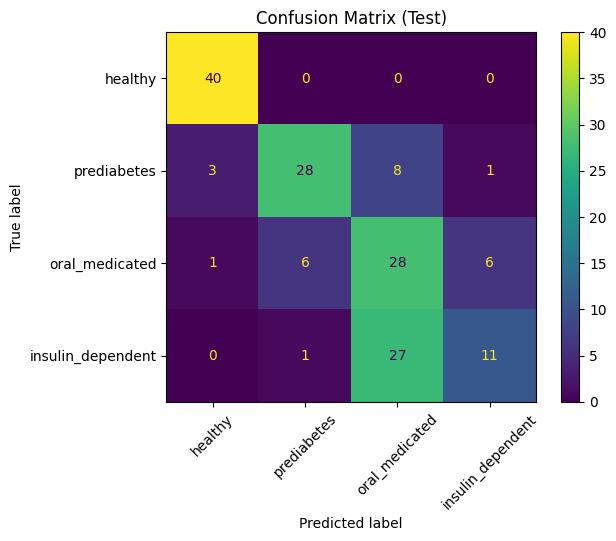

In [15]:
#Part A-Train MLP Properly

##############################
#1.)
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
#######################################

########################################
#2.)
import os, random
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
########################################

#--------------------------------------
# 1.) Build y from one-hot cols
#----------------------------------------
#Goal: Turn 4 one-hot target columns into a single multi-class label

target_cols = [
    "study_group_healthy",
    "study_group_pre_diabetes_lifestyle_controlled",
    "study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled",
    "study_group_insulin_dependent"
]

df[target_cols] = df[target_cols].astype(int)
print(df[target_cols].sum(axis=1).value_counts())

class_names = ["healthy", "prediabetes", "oral_medicated", "insulin_dependent"]

row_sums = df[target_cols].sum(axis=1)
print(row_sums.value_counts())
print("Bad rows (sum!=1):", (row_sums != 1).sum())

##########################

print("just before split section df columns (n):", df.shape[1])
print(df.columns.tolist())

#---------------------------
# 2.) Train/Val/Test Split use provided splits
#---------------------------
#Goal: Build feature matrices and class labels using the datasets pre made split columns

train_df = df[df["split_train"] == 1].copy()
val_df   = df[df["split_val"] == 1].copy()
test_df  = df[df["split_test"] == 1].copy()

#removing the target one-hot columns
drop_cols = target_cols + ["participant_id", "recommended_split", "split_train", "split_val", "split_test"]

#c is each column name, only include in the dataframe
X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
y_train = train_df[target_cols].values.argmax(axis=1)

# Make groups aligned with X_train rows
groups_train = train_df.loc[X_train.index, "participant_id"].to_numpy()

X_val = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns]).copy()
y_val = val_df[target_cols].values.argmax(axis=1)

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()
y_test = test_df[target_cols].values.argmax(axis=1)

##############################

#----------------------------------
# 3.) Preprocessor
#------------------------------------
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("X_train columns:", X_train.columns.tolist())
print("numeric_features (count):", len(numeric_features))
print("first numeric:", numeric_features[:20])
print("categorical_features (count):", len(categorical_features))
print("first categorical:", categorical_features[:20])

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

#Scales numeric columns, one-hot encodes categorical columns, handles missing values
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

#densify if sparse
#checks if its a sparse matrix
X_train_p = X_train_p.toarray() if hasattr(X_train_p, "toarray") else X_train_p
X_val_p   = X_val_p.toarray()   if hasattr(X_val_p, "toarray")   else X_val_p
X_test_p  = X_test_p.toarray()  if hasattr(X_test_p, "toarray")  else X_test_p

# capped class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
final_cw = dict(zip(classes, weights))
final_cw = {k: float(min(v, 6.0)) for k, v in final_cw.items()}

print("Train y bincount:", np.bincount(y_train, minlength=4))
print("Train one-hot sums:", train_df[target_cols].sum().to_dict())
#########################


#-----------------------
# 4.) MLP Builder
#------------------------
#Build and train the MLP

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

import tensorflow as tf

def sparse_focal_loss(gamma=4):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)

        # convert to one-hot
        y_true_onehot = tf.one_hot(y_true, depth=4)

        # numerical stability
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # cross entropy
        ce = -y_true_onehot * tf.math.log(y_pred)

        # focal scaling
        weight = tf.pow(1 - y_pred, gamma)

        fl = weight * ce

        return tf.reduce_sum(fl, axis=1)

    return loss

def build_mlp(n_in, n_out=4, lr=1e-3):
    model = Sequential([
        Input(shape=(n_in,)),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(n_out, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=sparse_focal_loss(gamma=2.5),
        metrics=["accuracy"]
    )

    return model

mlp = build_mlp(n_in=X_train_p.shape[1], n_out=4)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss", mode="min",
    patience=25, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5,
    patience=5, min_lr=1e-5
)

mlp.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
###########################


#--------------------------
# 5.) GroupKFold CV
#--------------------------
#Goal: Estimate performance robustly while precenting leakage between related samples

gkf = GroupKFold(n_splits=5)

fold_acc, fold_f1 = [], []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_train), start=1):

    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    # Fit preprocessor on X_tr only
    X_tr_p = preprocessor.fit_transform(X_tr)
    X_va_p = preprocessor.transform(X_va)

    X_tr_p = X_tr_p.toarray() if hasattr(X_tr_p, "toarray") else X_tr_p
    X_va_p = X_va_p.toarray() if hasattr(X_va_p, "toarray") else X_va_p

    classes = np.unique(y_tr)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    final_cw = dict(zip(classes, weights))

    # cap weights
    final_cw = {k: float(min(v, 4.5)) for k, v in final_cw.items()}
    print("class_weight:", final_cw)

    mlp = build_mlp(n_in=X_tr_p.shape[1], n_out=4)
    early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

    mlp.fit(X_tr_p, y_tr, class_weight=final_cw, validation_data=(X_va_p, y_va), epochs=200, batch_size=32,
            callbacks=[early_stop, reduce_lr], verbose=0)

    probs = mlp.predict(X_va_p, verbose=0)

    for t in [0.20, 0.25, 0.30, 0.35]:
        y_pred = np.argmax(probs, axis=1)
        y_pred[probs[:, 3] > t] = 3

        from sklearn.metrics import recall_score
        recall_ins = recall_score(y_va, y_pred, labels=[3], average=None)[0]
        print(f"Threshold {t} → Insulin Recall: {recall_ins:.3f}")

    # pick ONE threshold to score fold metrics (example: fixed at 0.25)
    t = 0.3
    y_pred = np.argmax(probs, axis=1)
    y_pred[probs[:, 3] > t] = 3

    fold_acc.append(accuracy_score(y_va, y_pred))
    fold_f1.append(f1_score(y_va, y_pred, average="weighted"))

    from sklearn.metrics import precision_score, recall_score, f1_score

    probs = mlp.predict(X_va_p, verbose=0)

    for t in [0.20, 0.25, 0.30, 0.35]:
        y_pred = np.argmax(probs, axis=1)
        y_pred[probs[:, 3] > t] = 3

        prec = precision_score(y_va, y_pred, labels=[3], average=None)[0]
        rec  = recall_score(y_va, y_pred, labels=[3], average=None)[0]
        f1   = f1_score(y_va, y_pred, labels=[3], average=None)[0]

        print(f"t={t:.2f}  insulin P={prec:.3f} R={rec:.3f} F1={f1:.3f}")


print("\n=== CV Summary (split_train only) ===")
print("CV Acc:", np.mean(fold_acc), "+/-", np.std(fold_acc))
print("CV F1 :", np.mean(fold_f1),  "+/-", np.std(fold_f1))
###############################


#------------------------
# 6.) Final Mode Training
#-------------------------
#Train one final model on TRAIN, tune/early-stop on VAL, then evaluate on TEST

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

X_train_p = X_train_p.toarray() if hasattr(X_train_p, "toarray") else X_train_p
X_val_p   = X_val_p.toarray() if hasattr(X_val_p, "toarray") else X_val_p
X_test_p  = X_test_p.toarray() if hasattr(X_test_p, "toarray") else X_test_p

# capped class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
final_cw = dict(zip(classes, weights))
final_cw = {k: float(min(v, 6.0)) for k, v in final_cw.items()}


#final_mlp = build_mlp(n_in=X_train_p.shape[1], n_out=4, seed=123)
final_mlp = build_mlp(n_in=X_train_p.shape[1], n_out=4)

early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

final_mlp.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=final_cw,
    verbose=0
)

y_test_pred = final_mlp.predict(X_test_p, verbose=0).argmax(axis=1)
print("Pred counts:", np.bincount(y_test_pred, minlength=4))
print("True counts:", np.bincount(y_test, minlength=4))

# ---------------------------
# 6.1 ) Extra of saving
# ---------------------------
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

# 1) Save the fitted preprocessor (VERY IMPORTANT)
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

# 2) Save class_names (optional, but nice)
joblib.dump(class_names, "artifacts/class_names.joblib")

# 3) Save model weights
final_mlp.save_weights("artifacts/final_mlp.weights.h5")

print("Saved: preprocessor + model weights to artifacts/")

# ----------------------------
# 7) Held-out test evaluation
# ----------------------------
#Goal: Evaluate once on TEST (data the model never saw during training or early stopping)

y_test_pred = final_mlp.predict(X_test_p, verbose=0).argmax(axis=1)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average="weighted")

print("\n=== Final Held-out Test Results ===")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Test W-F1:     {test_f1:.3f}")
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Test)")
plt.show()
##################################


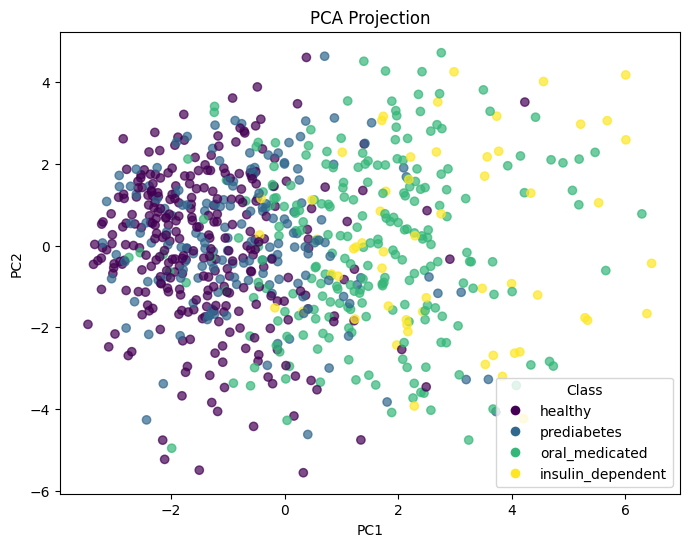

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_train_p)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y_train,
    cmap="viridis",
    alpha=0.7
)

# Create legend entries manually
class_names = ["healthy", "prediabetes", "oral_medicated", "insulin_dependent"]
handles = []

for i in range(len(class_names)):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=class_names[i],
            markerfacecolor=scatter.cmap(scatter.norm(i)),
            markersize=8
        )
    )

plt.legend(handles=handles, title="Class")
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

feature_names = [str(f) for f in preprocessor.get_feature_names_out()]

def class_one_vs_rest_accuracy(y_true, y_pred, class_idx):
    return accuracy_score((y_true == class_idx).astype(int), (y_pred == class_idx).astype(int))

def permutation_importance_per_class(model, X, y, class_idx, n_repeats=3, random_state=0):
    rng = np.random.default_rng(random_state)

    base_prob = model.predict(X, verbose=0)
    base_pred = base_prob.argmax(axis=1)
    base_score = class_one_vs_rest_accuracy(y, base_pred, class_idx)

    importances = np.zeros(X.shape[1], dtype=float)

    for j in range(X.shape[1]):
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            pred = model.predict(Xp, verbose=0).argmax(axis=1)
            drops.append(base_score - class_one_vs_rest_accuracy(y, pred, class_idx))
        importances[j] = np.mean(drops)

    return base_score, importances

for k, cname in enumerate(class_names):
    base, imp = permutation_importance_per_class(final_mlp, X_test_p, y_test, class_idx=k, n_repeats=3)
    top_idx = np.argsort(imp)[::-1][:20]

    print(f"\nClass: {cname} | baseline one-vs-rest acc={base:.3f}")
    for i in top_idx:
        print(f"{feature_names[i]}: {imp[i]:.5f}")



Class: healthy | baseline one-vs-rest acc=0.975
num__Pre-Diabetes: 0.19167
num__Type Ii Diabetes: 0.14792
num__Elevated A1C Levels (Elevated Blood Sugar: 0.08542
num__HbA1c: 0.01042
num__PR Interval: 0.00833
num__Sleep: 0.00833
num__High Blood Cholesterol: 0.00833
num__WBC: 0.00833
num__Osteoporosis: 0.00625
num__Low Blood Pressure: 0.00625
num__Arthritis (Joint Pain): 0.00625
num__Kidney Problems: 0.00625
num__Height: 0.00625
num__Insulin: 0.00625
num__Other Neurological Conditions: 0.00417
num__Respiratory Rate: 0.00417
num__RBC: 0.00208
num__Age: 0.00208
num__Heart Rate Pulse: 0.00208
num__Physical Activity: 0.00208

Class: prediabetes | baseline one-vs-rest acc=0.881
num__Pre-Diabetes: 0.15625
num__Type Ii Diabetes: 0.07083
num__Elevated A1C Levels (Elevated Blood Sugar: 0.06667
num__High Blood Cholesterol: 0.01667
num__PR Interval: 0.01667
num__Respiratory Rate: 0.01458
num__Sleep: 0.01250
num__WBC: 0.01250
num__BMI: 0.01042
num__HbA1c: 0.01042
num__Glucose: 0.01042
num__Insulin:

### Part B

In [18]:
# ============================================================
# Part B — Handling Hypothesis Questions
# ============================================================

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from sklearn.metrics import accuracy_score

# --------------------------
# 0) Utilities
# --------------------------
def densify(X):
    return X.toarray() if hasattr(X, "toarray") else X #makes it dense

def top2_from_probs(probs_row):
    """
    Returns the indices sorted from smallest to largest
    This being healthy, prediabetes, oral-medicated and insulin
    Then reverse the array
    THen picks the secondlargest probability
    Then returns the index of the two highest probaiblity, what the top is and then the margin
    Finds the most likely class, the second most likely class, and tells you how far apart they are.
    """
    order = np.argsort(probs_row)[::-1]
    top = int(order[0])
    runner = int(order[1])
    return top, runner, float(probs_row[top]), float(probs_row[runner]), float(probs_row[top] - probs_row[runner])


def predict_one(model, preprocessor, row_df):
    if isinstance(row_df, dict):
        row_df = pd.DataFrame([row_df])
    else:
        row_df = row_df.copy()

    # force all column names to strings
    row_df.columns = row_df.columns.map(str)

    # align to exactly what the preprocessor expects
    expected_cols = list(preprocessor.feature_names_in_)
    row_df = row_df.reindex(columns=expected_cols, fill_value=np.nan)

    Xp = densify(preprocessor.transform(row_df))
    probs = model.predict(Xp, verbose=0)[0]
    top, runner, top_conf, runner_conf, margin = top2_from_probs(probs)

    return {
        "top_class": IDX_TO_LABEL[top],
        "top_conf": float(top_conf),
        "runner_class": IDX_TO_LABEL[runner],
        "runner_conf": float(runner_conf),
        "margin": float(margin),
        "probs": {IDX_TO_LABEL[i]: float(probs[i]) for i in range(len(probs))}
    }

In [19]:

# --------------------------
# 1) Import in the MLP weights (+ preprocessor)
# --------------------------
preprocessor = joblib.load("artifacts/preprocessor.joblib") # preprocessing
class_names  = joblib.load("artifacts/class_names.joblib")  # ["healthy","prediabetes","oral_medicated","insulin_dependent"]

# infer n_in robustly (no .toarray() error)
X1 = preprocessor.transform(X_train.iloc[:1])  # X_train from Part A
n_in = densify(X1).shape[1]

mlp_loaded = build_mlp(n_in=n_in, n_out=4)
mlp_loaded.load_weights("artifacts/final_mlp.weights.h5")
print("Loaded weights. Input dim:", n_in)
# Loads the wights


Loaded weights. Input dim: 48


C:\Users\winon\Downloads\Module2\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
# --------------------------
# 2) Apply Features (canonical feature columns = training X columns)
# --------------------------
FEATURE_COLS = X_train.columns.tolist()
print(FEATURE_COLS)

['Age', 'Heart Rate Pulse', 'Oxygen Saturation', 'Physical Activity', 'Sleep', 'Stress', 'Respiratory Rate', 'Blood Glucose', 'PR Interval', 'Age-Related Macular Degeneration (Am', 'Arthritis (Joint Pain)', 'Cancer (Any Type)', 'Cataracts (In One Or Both Eyes)', 'Chronic Pulmonary (Lung) Problems (E', 'Circulation Problems (Examples: Art', "Dementia (Examples: Alzheimer'S Disea", 'Diabetic Retinopathy (In One Or Both', 'Digestive Problems (Examples: Stomach', 'Do You Use Marijuana Now?', 'Dry Eye (In One Or Both Eyes)', 'Elevated A1C Levels (Elevated Blood Sugar', 'Glaucoma (In One Or Both Eyes)', 'Hearing Impairment', 'Heart Attack', 'High Blood Cholesterol', 'High Blood Pressure', 'Kidney Problems', 'Low Blood Pressure', 'Mild Cognitive Impairment (Known As', 'Multiple Sclerosis', 'Obesity', 'Osteoporosis', 'Other Heart Issues (Examples: Pace', 'Other Neurological Conditions', "Parkinson'S Disease", 'Pre-Diabetes', 'Retinal Vascular Occlusion ("Stroke', 'Stroke', 'Type Ii Diabetes', 

In [21]:
# --------------------------
# 3) Set Boundaries (uses your BOUNDARIES dict)
# --------------------------
#################################
#Boundaries

BOUNDARIES = {
    "HbA1c": (4, 6.5),
    "Heart Rate Pulse": (60, 100),
    "Oxygen Saturation": (95, 100),
    "Physical Activity": (3867, 10000),
    "Sleep": (0.29, 0.375),
    "Stress": (0, 100),
    "PR Interval": (120, 200),
    "Blood Glucose": (72, 160),
    "Age": (44, 65),
    "RBC": (3.92, 5.65),
    "WBC": (4, 11),
    "BMI": (18.5, 30),
    "Glucose": (62, 125),
    "Height": (161, 175),
    "Cholesterol": (0, 200),
    "Insulin": (0.5, 3),
    "Respiratory Rate": (0, 1),
}
#################################

def boundary_value(col, level="normal"):
    """
    Checks that the column has boundaries
    Extracts the bounds e.g. defines what is low and high
    If level is low will output lo
    If level is high will output hi
    e.g. this translate the question so low HbA1c will output <4
    """
    if col not in BOUNDARIES:
        raise KeyError(f"'{col}' not found in BOUNDARIES")
    lo, hi = BOUNDARIES[col]
    if level == "low":
        return float(lo)
    if level == "high":
        return float(hi)
    return float((lo + hi) / 2)

    # numeric vars = boundary keys present in master

numeric_query_vars = [k for k in BOUNDARIES.keys() if k in master.columns and k not in drop_cols]

condition_vars = [
    c for c in master.columns
    if c not in drop_cols
    and master[c].dropna().isin([0, 1]).all()
]

condition_vars = list(set(condition_vars))

In [22]:
# --------------------------
# 4.1) Create Standard Patient (midpoint of each boundary everything else 0)
# --------------------------

def is_binary_column(df, col):
    """
    Checks whether the column is a binary feature e.g. the categories
    Removes missing Values
    Makes sure Column isn't empty
    """
    vals = set(df[col].dropna().unique())
    return vals.issubset({0, 1}) and len(vals) > 0


def make_standard_patient(df_raw, feature_cols):
    """
    Baseline logic:
      - binary column (0/1) -> 0
      - numeric + boundary -> midpoint
      - numeric no boundary -> dataset median
      - otherwise -> 0
    """
    row = {}

    for col in feature_cols: #looks through the model's training column

        # If column doesn't exist in raw df
        if col not in df_raw.columns:
            row[col] = 0.0
            continue

        # 1️⃣ Binary columns → 0
        if is_binary_column(df_raw, col): #makes sure won't have any other categories
            row[col] = 0.0

        # 2️⃣ Numeric with boundary → midpoint #sets any numerical to midpoint
        elif col in BOUNDARIES:
            lo, hi = BOUNDARIES[col]
            row[col] = float((lo + hi) / 2)

        # 3️⃣ Numeric without boundary → median #makes sure there is not outlier
        elif np.issubdtype(df_raw[col].dtype, np.number):
            row[col] = float(df_raw[col].median())

        # 4️⃣ Fallback #if unsure will output 0
        else:
            row[col] = 0.0

    return pd.DataFrame([row], columns=feature_cols)

standard_patient = make_standard_patient(df, FEATURE_COLS)

print("Standard patient created.")
print(standard_patient)

Standard patient created.
    Age  Heart Rate Pulse  Oxygen Saturation  Physical Activity   Sleep  \
0  54.5              80.0               97.5             6933.5  0.3325   

   Stress  Respiratory Rate  Blood Glucose  PR Interval  \
0    50.0               0.5          116.0        160.0   

   Age-Related Macular Degeneration (Am  ...  Type Ii Diabetes  \
0                                   0.0  ...               0.0   

   Urinary Problems (Examples: Urinary T    BMI  Cholesterol  Glucose  HbA1c  \
0                                    0.0  24.25        100.0     93.5   5.25   

   Height  Insulin    RBC  WBC  
0   168.0     1.75  4.785  7.5  

[1 rows x 48 columns]


In [23]:
# --------------------------
# 4.2) Create Standard Patients (for each subgroup)
# --------------------------

def get_true_label_index(df_raw):
    # Converts the 4 on-hot columns into a single integer class label 0,1,2,3
    return df_raw[target_cols].astype(int).values.argmax(axis=1)


def make_standard_subgroup(df_sub, feature_cols):
    """
    Makes a standard patient for each class -> healthy, prediabetes, oral_medicated, insulin
    mode for binary, median for numeric.
    """
    row = {}
    for c in feature_cols:
        if c not in df_sub.columns:
            row[c] = 0.0
            continue

        s = df_sub[c]
        if is_binary_column(df_sub, c):
            # mode for binary e.g. what comes up the most
            vals = s.dropna()
            row[c] = float(vals.mode().iloc[0]) if len(vals) else 0.0
        else:
            # median for numeric e.g. adding up all the values so to find an average
            row[c] = float(pd.to_numeric(s, errors="coerce").median())
    return pd.DataFrame([row], columns=feature_cols)

def build_prototypes_by_true_group(df_raw):
    """
    Splits the dataset into true label groups
    Build prototype one per group
    So will pick only the patients fomr the TRUE class
    Creates a dictionary with healthy, prediabetes, oral_medicated, insulin_dependent

    """
    y_idx = get_true_label_index(df_raw)
    prototypes = {}

    for k, name in enumerate(class_names):
        grp = df_raw.loc[y_idx == k].copy()
        prototypes[name] = make_standard_subgroup(grp, FEATURE_COLS)

    return prototypes

prototypes = build_prototypes_by_true_group(df)
print("Standard Subgroups:", list(prototypes.keys()))

Standard Subgroups: ['healthy', 'prediabetes', 'oral_medicated', 'insulin_dependent']


In [24]:
# --------------------------
# 4.3) Predict fake patient with MLP
# --------------------------
def predict_one(model, preprocessor, row_df):
    Xp = densify(preprocessor.transform(row_df))
    probs = model.predict(Xp, verbose=0)[0]
    top, runner, top_conf, runner_conf, margin = top2_from_probs(probs)
    return {
        "probs": probs,
        "top_idx": top,
        "top_class": class_names[top],
        "top_conf": top_conf,
        "runner_class": class_names[runner],
        "runner_conf": runner_conf,
        "margin": margin,
    }



In [25]:
# --------------------------
# 5) Ask Question
# Mode: mixed
# Question: Does HIGH Physical Activity and Type Ii Diabetes affect likelihood of T2DM category?
# --------------------------
def manual_query(master, numeric_vars, condition_vars, mode="manual"):
    """
    Manual version of random_query.
    Returns: (var1, level1, var2, level2, mode_used)
    """

    available_modes = ["numeric2", "cond2", "mixed", "single"]

    print("Available modes:")
    for m in available_modes:
        print("-", m)

    while True:
        mode_used = input("Choose mode: ").strip().lower()
        if mode_used in available_modes:
            break
        print(f"❌ Invalid mode. Choose one of: {available_modes}")

    if mode_used == "single":
        while True:
            kind = input("Choose feature type ('numeric' or 'condition'): ").strip().lower()
            if kind in ["numeric", "condition"]:
                break
            print("❌ Invalid choice. Type 'numeric' or 'condition'.")

        if kind == "numeric":
            print("\nNumeric features:")
            for f in numeric_vars:
                print("-", f)

            while True:
                var1 = input("Choose numeric feature: ").strip()
                if var1 in numeric_vars:
                    break
                print("❌ Invalid feature. Please choose from the list.")

            valid_levels = ["LOW", "NORMAL", "HIGH"]
            while True:
                level1 = input("Choose level (LOW / NORMAL / HIGH): ").strip().upper()
                if level1 in valid_levels:
                    break
                print("❌ Invalid level. Choose LOW, NORMAL, or HIGH.")

            return var1, level1, None, None, "single"

        elif kind == "condition":
            print("\nCondition features:")
            for f in condition_vars:
                print("-", f)

            while True:
                var1 = input("Choose condition feature: ").strip()
                if var1 in condition_vars:
                    break
                print("❌ Invalid condition. Please choose from the list.")

            return var1, None, None, None, "single"

    if mode_used == "numeric2":
        print("\nNumeric features:")
        for f in numeric_vars:
            print("-", f)

        while True:
            var1 = input("Choose first numeric feature: ").strip()
            if var1 in numeric_vars:
                break
            print("❌ Invalid feature. Please choose from the list.")

        while True:
            level1 = input("Choose first level (LOW / HIGH): ").strip().upper()
            if level1 in ["LOW", "HIGH"]:
                break
            print("❌ Invalid level. Choose LOW or HIGH.")

        while True:
            var2 = input("Choose second numeric feature: ").strip()
            if var2 in numeric_vars:
                break
            print("❌ Invalid feature. Please choose from the list.")

        while True:
            level2 = input("Choose second level (LOW / HIGH): ").strip().upper()
            if level2 in ["LOW", "HIGH"]:
                break
            print("❌ Invalid level. Choose LOW or HIGH.")

        return var1, level1, var2, level2, "numeric2"

    if mode_used == "cond2":
        print("\nCondition features:")
        for f in condition_vars:
            print("-", f)

        while True:
            var1 = input("Choose first condition feature: ").strip()
            if var1 in condition_vars:
                break
            print("❌ Invalid condition. Please choose from the list.")

        while True:
            var2 = input("Choose second condition feature: ").strip()
            if var2 in condition_vars:
                break
            print("❌ Invalid condition. Please choose from the list.")

        return var1, None, var2, None, "cond2"

    if mode_used == "mixed":
        print("\nNumeric features:")
        for f in numeric_vars:
            print("-", f)

        while True:
            var1 = input("Choose numeric feature: ").strip()
            if var1 in numeric_vars:
                break
            print("❌ Invalid feature. Try again.")

        while True:
            level1 = input("Choose level (LOW / HIGH): ").strip().upper()
            if level1 in ["LOW", "HIGH"]:
                break
            print("❌ Invalid level. Choose LOW or HIGH.")

        print("\nCondition features:")
        for f in condition_vars:
            print("-", f)

        while True:
            var2 = input("Choose condition feature: ").strip()
            if var2 in condition_vars:
                break
            print("❌ Invalid condition. Try again.")

        return var1, level1, var2, None, "mixed"
        


In [26]:
# Generate a hypothesis
var1, level1, var2, level2, mode_used = manual_query(
    master=master,
    numeric_vars=numeric_query_vars,
    condition_vars=condition_vars
)

Available modes:
- numeric2
- cond2
- mixed
- single


Choose mode:  mixed



Numeric features:
- HbA1c
- Heart Rate Pulse
- Oxygen Saturation
- Physical Activity
- Sleep
- Stress
- PR Interval
- Blood Glucose
- Age
- RBC
- WBC
- BMI
- Glucose
- Height
- Cholesterol
- Insulin
- Respiratory Rate


Choose numeric feature:  Glucose
Choose level (LOW / HIGH):  HIGH



Condition features:
- Dry Eye (In One Or Both Eyes)
- Stroke
- Age-Related Macular Degeneration (Am
- Osteoporosis
- Mild Cognitive Impairment (Known As
- Cancer (Any Type)
- Pre-Diabetes
- Chronic Pulmonary (Lung) Problems (E
- Hearing Impairment
- High Blood Cholesterol
- Glaucoma (In One Or Both Eyes)
- Kidney Problems
- Other Neurological Conditions
- Cataracts (In One Or Both Eyes)
- Circulation Problems (Examples: Art
- Retinal Vascular Occlusion ("Stroke
- Low Blood Pressure
- Elevated A1C Levels (Elevated Blood Sugar
- High Blood Pressure
- Heart Attack
- Dementia (Examples: Alzheimer'S Disea
- Other Heart Issues (Examples: Pace
- Arthritis (Joint Pain)
- Multiple Sclerosis
- Digestive Problems (Examples: Stomach
- Diabetic Retinopathy (In One Or Both
- Do You Use Marijuana Now?
- Parkinson'S Disease
- Urinary Problems (Examples: Urinary T
- Obesity
- Type Ii Diabetes


Choose condition feature:  Retinal Vascular Occlusion ("Stroke


In [27]:
# --------------------------
# 6) Change Standard Patient columns for the hypothesis
#    HIGH Physical Activity -> set to boundary high
#    Type Ii Diabetes -> set to 1 (flag)
# --------------------------
def changes_for_var(var, level, condition_vars):
    """
    Returns the 'changes' list used by apply_changes.
    - If level is not None -> numeric boundary variable (LOW/NORMAL/HIGH)
    - Else -> binary variable, set to 1
    """
    if level is None:
        return [{"col": var, "type": "value", "value": 1.0}]
    else:
        return [{"col": var, "type": "boundary", "level": str(level).lower()}]  # expects "low/high/normal"

#fake_patient = apply_changes(standard_patient, hypothesis_changes)


In [28]:
# Convert variables into change instructions
changes1 = changes_for_var(var1, level1, condition_vars)

changes2 = []
if var2 is not None:
    changes2 = changes_for_var(var2, level2, condition_vars)

hypothesis_changes = changes1 + changes2

print("Hypothesis changes:", hypothesis_changes)

Hypothesis changes: [{'col': 'Glucose', 'type': 'boundary', 'level': 'high'}, {'col': 'Retinal Vascular Occlusion ("Stroke', 'type': 'value', 'value': 1.0}]


In [29]:
# --------------------------
# 7.1) Sanity Checking Standard Patients (for each subgroup)
# --------------------------
def predict_label_and_probs(row_df):
    res = predict_one(mlp_loaded, preprocessor, row_df)
    return res["top_class"], res["top_conf"], res["probs"]

print("\nPrototype sanity check:")
for name, proto in prototypes.items():
    pred, conf, _ = predict_label_and_probs(proto)
    print(f"Prototype built from TRUE {name:>16} -> model predicts {pred:>16} (conf={conf:.2f})")


Prototype sanity check:
Prototype built from TRUE          healthy -> model predicts          healthy (conf=0.98)
Prototype built from TRUE      prediabetes -> model predicts      prediabetes (conf=0.89)
Prototype built from TRUE   oral_medicated -> model predicts   oral_medicated (conf=0.86)
Prototype built from TRUE insulin_dependent -> model predicts   oral_medicated (conf=0.82)


In [30]:
def apply_changes(patient_df, changes):
    out = patient_df.copy()
    for ch in changes:
        col = ch["col"]
        if ch.get("type") == "boundary":
            out.loc[:, col] = boundary_value(col, ch["level"])
        else:
            out.loc[:, col] = ch["value"]
    return out

In [31]:
# --------------------------
# 7.1) Run hypothesis on all prototypes
# --------------------------
def run_hypothesis_on_all_prototypes(prototypes, changes):
    results = []

    for group_name, proto in prototypes.items():

        base_res = predict_one(mlp_loaded, preprocessor, proto)

        changed = apply_changes(proto, changes)
        changed_res = predict_one(mlp_loaded, preprocessor, changed)

        delta = changed_res["probs"] - base_res["probs"]

        results.append({
            "subgroup": group_name,   # ← renamed here
            "baseline_pred": base_res["top_class"],
            "baseline_conf": base_res["top_conf"],
            "changed_pred": changed_res["top_class"],
            "changed_conf": changed_res["top_conf"],
            "delta_healthy": float(delta[0]),
            "delta_prediabetes": float(delta[1]),
            "delta_oral_medicated": float(delta[2]),
            "delta_insulin_dependent": float(delta[3]),
        })

    return pd.DataFrame(results)

res_df = run_hypothesis_on_all_prototypes(prototypes, hypothesis_changes)
res_df

,subgroup,baseline_pred,baseline_conf,changed_pred,changed_conf,delta_healthy,delta_prediabetes,delta_oral_medicated,delta_insulin_dependent
0,healthy,healthy,0.984860,healthy,0.509287,-0.475573,0.412361,0.041702,0.021510
1,prediabetes,prediabetes,0.894164,prediabetes,0.932439,0.011505,0.038275,-0.043095,-0.006686
2,oral_medicated,oral_medicated,0.855274,oral_medicated,0.639396,-0.001290,-0.016290,-0.215878,0.233459
3,insulin_dependent,oral_medicated,0.824706,oral_medicated,0.524185,-0.002026,-0.009071,-0.300521,0.311618


In [32]:
# --------------------------
# 8) Find all dataset patients that fit the hypothesis
#    HIGH Physical Activity = >= upper boundary
#    Type Ii Diabetes = 1
# --------------------------
def subset_dataset(df_raw, changes):
    mask = pd.Series(True, index=df_raw.index)
    for ch in changes:
        col = ch["col"]
        if col not in df_raw.columns:
            raise KeyError(f"Column '{col}' not in df.")
        if ch.get("type") == "boundary":
            lo, hi = BOUNDARIES[col]
            if ch["level"] == "high":
                mask &= df_raw[col].astype(float) >= float(hi)
            elif ch["level"] == "low":
                mask &= df_raw[col].astype(float) <= float(lo)
            else:
                mask &= df_raw[col].astype(float).between(float(lo), float(hi), inclusive="both")
        else:
            mask &= (df_raw[col].astype(float) == float(ch["value"]))
    return df_raw[mask].copy()

sub_df = subset_dataset(df, hypothesis_changes)   # df is your full raw dataset
n_sub = len(sub_df)

# predict subgroup (if any)
if n_sub > 0:
    X_sub = sub_df[FEATURE_COLS].copy()
    X_sub_p = densify(preprocessor.transform(X_sub))
    sub_probs = mlp_loaded.predict(X_sub_p, verbose=0)
    sub_pred = sub_probs.argmax(axis=1)

    # distribution + majority
    counts = np.bincount(sub_pred, minlength=4)
    majority_idx = int(np.argmax(counts))
    majority_name = class_names[majority_idx]
    majority_share = float(counts[majority_idx] / n_sub)

    # confidence summaries
    mean_top_conf = float(np.max(sub_probs, axis=1).mean())
    order = np.argsort(sub_probs, axis=1)[:, ::-1]
    margins = sub_probs[np.arange(n_sub), order[:, 0]] - sub_probs[np.arange(n_sub), order[:, 1]]
    mean_margin = float(margins.mean())
else:
    majority_name = None
    majority_share = None
    mean_top_conf = None
    mean_margin = None

In [33]:
prototypes = build_prototypes_by_true_group(df)  # dict: class_name -> 1-row df

In [34]:
def describe_var(var, level, condition_vars):
    """
    Turn a variable + level into readable text for the question header.
    """
    if level is None:
        return str(var)
    return f"{str(level).upper()} {str(var)}"

# ASking Question

In [35]:
# --------------------------
# 9) Output Sentence Block (baseline + fake + dataset)
# --------------------------


def class_distribution_text(pred_labels, class_names):
    counts = np.bincount(pred_labels, minlength=len(class_names))
    total = counts.sum()
    order = np.argsort(counts)[::-1]

    lines = []
    for idx in order:
        if counts[idx] == 0:
            continue
        pct = counts[idx] / total
        lines.append(f"{class_names[idx]}: {counts[idx]}/{total} ({pct:.1%})")

    return ", ".join(lines)


def predicted_class_condition_breakdown(all_pred, sub_pred, class_names):
    """
    For each predicted class in the full dataset:
    how many of those predicted patients fall inside the condition
    """
    total_counts = np.bincount(all_pred, minlength=len(class_names))
    sub_counts = np.bincount(sub_pred, minlength=len(class_names))

    lines = []
    for i, name in enumerate(class_names):
        total = total_counts[i]
        in_condition = sub_counts[i]
        pct = 0.0 if total == 0 else in_condition / total
        lines.append(f"{name}: {in_condition}/{total} ({pct:.1%})")
    return lines
    
def compare_independent_effects(
    df,
    var1, level1,      # example: "Physical Activity", "HIGH"
    var2, level2,      # example: "Type Ii Diabetes", None
    condition_vars,    # set of binary 0/1 columns
    preprocessor,
    mlp,
    drop_cols,
    test_acc,
    prototypes=None,
    show_joint=True
):
    # 1) Base Patient
    # -------------------------
    # QUESTION HEADER (NEW)
    # -------------------------

    X_all = df[FEATURE_COLS].copy()

    s1 = describe_var(var1, level1, set(condition_vars))

    if var2 is None:
        question_line = f"Does {s1} affect likelihood of T2DM category?"
    else:
        s2 = describe_var(var2, level2, set(condition_vars))
        question_line = f"Does {s1} AND {s2} affect likelihood of T2DM category?"
              
    
    base_patient = make_standard_patient(df, FEATURE_COLS)
    base_res = predict_one(mlp, preprocessor, base_patient)

    # 1.1) Fake Patient(Median)
    # Base fake patient (median/midpoint baseline)
    base_patient = make_standard_patient(df, FEATURE_COLS)

    # Build changes for question

    changes1 = changes_for_var(var1, level1, condition_vars)

    changes2 = []
    if var2 is not None:
        changes2 = changes_for_var(var2, level2, condition_vars)
    
    changes_joint = changes1 + changes2


    # Fake patient that matches the full question (joint)
    fake_question_patient = apply_changes(base_patient, changes_joint)
    fake_question_res = predict_one(mlp, preprocessor, fake_question_patient)

    fake_aligned = fake_question_patient.reindex(columns=base_patient.columns, fill_value=np.nan)

    changed_cols = fake_aligned.iloc[0].ne(base_patient.iloc[0])
    print("Changed columns:", list(base_patient.columns[changed_cols]))

    # 2) Changed Patient (Var1 only)
    changes1 = []
    if level1 is not None:  # var1 is numeric
        changes1.append({"col": var1, "type": "boundary", "level": level1})
    else: # var1 is binary
        changes1.append({"col": var1, "type": "value", "value": 1.0})

    patient1 = apply_changes(base_patient, changes1)
    res1 = predict_one(mlp, preprocessor, patient1)

    
    # 3) Changed Patient (Var2 only)

    res2 = None
    sub_df2 = pd.DataFrame()
    
    if var2 is not None:
        changes2 = []
        if level2 is not None:
            changes2.append({"col": var2, "type": "boundary", "level": level2})
        else:
            changes2.append({"col": var2, "type": "value", "value": 1.0})
    
        patient2 = apply_changes(base_patient, changes2)
        res2 = predict_one(mlp, preprocessor, patient2)
    
    # 4) Changed Patient (Joint)
    if show_joint:
        changes_joint = changes1 + changes2
        patient_joint = apply_changes(base_patient, changes_joint)
        res_joint = predict_one(mlp, preprocessor, patient_joint)

    # 5) Subsetting the dataset
    sub_df1 = subset_dataset(df, changes1)
    sub_df2 = subset_dataset(df, changes2)
    sub_df_joint = subset_dataset(df, changes_joint) if show_joint else pd.DataFrame()

    def get_impact_description(delta_probs):
        if abs(delta_probs) > 0.3: return "High"
        if abs(delta_probs) > 0.1: return "Moderate"
        return "Low"

    def get_confidence_description(conf):
        if conf > 0.8: return "High"
        if conf > 0.5: return "Moderate"
        return "Low"

    report = question_line
    report += f"Baseline prediction for average patient: {base_res['top_class']} (conf={base_res['top_conf']:.2f})\n\n"

    # Var1 report
    var1_desc = f"{level1 or ''} {var1}".strip()
    report += f"Effect of {var1_desc}:\n"
    report += f"  Predicted class: {res1['top_class']} (conf={res1['top_conf']:.2f})\n"
    report += f"  Delta to baseline: {get_impact_description(res1['top_conf'] - base_res['top_conf'])} ({res1['top_conf'] - base_res['top_conf']:.2f})\n"
    
    if not sub_df1.empty:
        X_sub1_p = densify(preprocessor.transform(sub_df1[FEATURE_COLS]))
        sub_pred1 = mlp.predict(X_sub1_p, verbose=0).argmax(axis=1)
    
        dist_text = class_distribution_text(sub_pred1, class_names)
        report += (
            f"  Among patients with {var1_desc} ({len(sub_df1)} patients), "
            f"the predicted class distribution is: {dist_text}.\n"
        )
    
       # lines1 = predicted_class_condition_breakdown(all_pred, sub_pred1, class_names)
        #report += f"  Out of all predicted patients:\n"
        #for line in lines1:
         #   report += f"    - {line} have {var1_desc}\n"
        #report += "\n"
    #else:
     #   report += f"  No patients found in dataset with {var1_desc}.\n\n"
    

    # Var2 report
    if var2 is not None:
        var2_desc = f"{level2 or ''} {var2}".strip()
        report += f"Effect of {var2_desc}:\n"
        report += f"  Predicted class: {res2['top_class']} (conf={res2['top_conf']:.2f})\n"
        report += f"  Delta to baseline: {get_impact_description(res2['top_conf'] - base_res['top_conf'])} ({res2['top_conf'] - base_res['top_conf']:.2f})\n"
    
        if not sub_df2.empty:
            X_sub2_p = densify(preprocessor.transform(sub_df2[FEATURE_COLS]))
            sub_pred2 = mlp.predict(X_sub2_p, verbose=0).argmax(axis=1)
    
            dist_text = class_distribution_text(sub_pred2, class_names)
            report += (
                f"  Among patients with {var2_desc} ({len(sub_df2)} patients), "
                f"the predicted class distribution is: {dist_text}.\n"
            )
            X_all = df.drop(columns=drop_cols, errors="ignore").copy()
            X_all_p = densify(preprocessor.transform(X_all))
            all_probs = mlp.predict(X_all_p, verbose=0)
            all_pred = all_probs.argmax(axis=1)
            lines2 = predicted_class_condition_breakdown(all_pred, sub_pred2, class_names)
           # report += f"  Out of all predicted patients:\n"
            #for line in lines2:
             #   report += f"    - {line} have {var2_desc}\n"
            #report += "\n"
        #else:
         #   report += f"  No patients found in dataset with {var2_desc}.\n\n"
            
    # Joint report
    if show_joint and var2 is not None:
        joint_desc = f"{var1_desc} AND {var2_desc}"
        report += f"Combined effect of {joint_desc}:\n"
        report += f"  Predicted class: {res_joint['top_class']} (conf={res_joint['top_conf']:.2f})\n"
        report += f"  Delta to baseline: {get_impact_description(res_joint['top_conf'] - base_res['top_conf'])} ({res_joint['top_conf'] - base_res['top_conf']:.2f})\n"
    
        if not sub_df_joint.empty:
            X_sub_joint_p = densify(preprocessor.transform(sub_df_joint[FEATURE_COLS]))
            sub_pred_joint = mlp.predict(X_sub_joint_p, verbose=0).argmax(axis=1)
    
            dist_text = class_distribution_text(sub_pred_joint, class_names)
            report += (
                f"  Among patients with {joint_desc} ({len(sub_df_joint)} patients), "
                f"the predicted class distribution is: {dist_text}.\n"
            )
    
            lines_joint = predicted_class_condition_breakdown(all_pred, sub_pred_joint, class_names)
           # report += f"  Out of all predicted patients:\n"
           # for line in lines_joint:
            #    report += f"    - {line} have {joint_desc}\n"
            #report += "\n"
        #else:
         #   report += f"  No patients found in dataset with {joint_desc}.\n\n"

    
    # -------------------------
    # Subgroup prototype fake patients (NEW)
    # -------------------------
    if prototypes is not None:
        report += "Fake patients by TRUE subgroup (before → after applying question):\n"

        for true_group_name, proto in prototypes.items():
            base_p = predict_one(mlp, preprocessor, proto)

            changed_proto = apply_changes(proto, changes_joint)
            changed_p = predict_one(mlp, preprocessor, changed_proto)

            report += (
                f"  - Prototype TRUE {true_group_name}: "
                f"{base_p['top_class']} ({base_p['top_conf']:.2f}) → "
                f"{changed_p['top_class']} ({changed_p['top_conf']:.2f}) "
                f"[Δhealthy={changed_p['probs'][0]-base_p['probs'][0]:+.2f}, "
                f"Δpred={changed_p['probs'][1]-base_p['probs'][1]:+.2f}, "
                f"Δoral={changed_p['probs'][2]-base_p['probs'][2]:+.2f}, "
                f"Δins={changed_p['probs'][3]-base_p['probs'][3]:+.2f}]"
                "\n"
            )

        report += "\n"

    
    return report, base_res, fake_question_res, sub_df_joint, 5

import random
import pandas as pd
import json

def run_n_manual_questions(
    master,
    numeric_vars,
    condition_vars,
    preprocessor, mlp, drop_cols,
    test_acc,
    n=5,
    show_joint=True,
):
    results = []

    for i in range(1, n + 1):
        print("\n" + "=" * 70)
        print(f"Question {i}")
        print("=" * 70)

        var1, level1, var2, level2, mode_used = manual_query(
            master=master,
            numeric_vars=numeric_vars,
            condition_vars=condition_vars
        )

        s1 = describe_var(var1, level1, set(condition_vars))

        if var2 is None:
            question_text = f"Does {s1} affect likelihood of T2DM category?"
        else:
            s2 = describe_var(var2, level2, set(condition_vars))
            question_text = f"Does {s1} AND {s2} affect likelihood of T2DM category?"

        report, base_res, fake_question_res, sub_df_joint, extra_val = compare_independent_effects(
            df=master,
            var1=var1, level1=level1,
            var2=var2, level2=level2,
            condition_vars=set(condition_vars),
            preprocessor=preprocessor,
            mlp=mlp,
            drop_cols=drop_cols,
            test_acc=test_acc,
            show_joint=show_joint,
            prototypes=prototypes
        )

        results.append({
            "run_id": i,
            "mode_used": mode_used,
            "var1": var1,
            "level1": level1,
            "var2": var2,
            "level2": level2,
            "question_text": question_text,
            "report": report,
            "baseline_top_class": base_res["top_class"],
            "baseline_top_conf": base_res["top_conf"],
            "fake_top_class": fake_question_res["top_class"],
            "fake_top_conf": fake_question_res["top_conf"],
            "runner_up_class": fake_question_res["runner_class"],
            "margin": fake_question_res["margin"],
            "subset_joint_size": len(sub_df_joint) if sub_df_joint is not None else 0
        })

    return results
    
results = run_n_manual_questions(
    master=master,
    numeric_vars=numeric_query_vars,
    condition_vars=condition_vars,
    preprocessor=preprocessor,
    mlp=mlp_loaded,
    drop_cols=drop_cols,
    test_acc=test_acc,
    n=1,
    show_joint=True
)

for r in results:
    print("\n" + "=" * 60)
    print(f"Question {r['run_id']} | Mode={r['mode_used']}")
    print("Question:", r["question_text"])
    print()
    print(r["report"])

df_results = pd.DataFrame(results)
df_results.to_csv("random_question_results.csv", index=False)


Question 1
Available modes:
- numeric2
- cond2
- mixed
- single


Choose mode:  mixed



Numeric features:
- HbA1c
- Heart Rate Pulse
- Oxygen Saturation
- Physical Activity
- Sleep
- Stress
- PR Interval
- Blood Glucose
- Age
- RBC
- WBC
- BMI
- Glucose
- Height
- Cholesterol
- Insulin
- Respiratory Rate


Choose numeric feature:  Glucose
Choose level (LOW / HIGH):  HIGH



Condition features:
- Dry Eye (In One Or Both Eyes)
- Stroke
- Age-Related Macular Degeneration (Am
- Osteoporosis
- Mild Cognitive Impairment (Known As
- Cancer (Any Type)
- Pre-Diabetes
- Chronic Pulmonary (Lung) Problems (E
- Hearing Impairment
- High Blood Cholesterol
- Glaucoma (In One Or Both Eyes)
- Kidney Problems
- Other Neurological Conditions
- Cataracts (In One Or Both Eyes)
- Circulation Problems (Examples: Art
- Retinal Vascular Occlusion ("Stroke
- Low Blood Pressure
- Elevated A1C Levels (Elevated Blood Sugar
- High Blood Pressure
- Heart Attack
- Dementia (Examples: Alzheimer'S Disea
- Other Heart Issues (Examples: Pace
- Arthritis (Joint Pain)
- Multiple Sclerosis
- Digestive Problems (Examples: Stomach
- Diabetic Retinopathy (In One Or Both
- Do You Use Marijuana Now?
- Parkinson'S Disease
- Urinary Problems (Examples: Urinary T
- Obesity
- Type Ii Diabetes


Choose condition feature:  Retinal Vascular Occlusion ("Stroke


Changed columns: ['Retinal Vascular Occlusion ("Stroke', 'Glucose']

Question 1 | Mode=mixed
Question: Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect likelihood of T2DM category?

Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect likelihood of T2DM category?Baseline prediction for average patient: healthy (conf=0.98)

Effect of HIGH Glucose:
  Predicted class: healthy (conf=0.98)
  Delta to baseline: Low (0.00)
  Among patients with HIGH Glucose (861 patients), the predicted class distribution is: healthy: 358/861 (41.6%), oral_medicated: 228/861 (26.5%), prediabetes: 223/861 (25.9%), insulin_dependent: 52/861 (6.0%).
Effect of Retinal Vascular Occlusion ("Stroke:
  Predicted class: healthy (conf=0.54)
  Delta to baseline: High (-0.44)
  Among patients with Retinal Vascular Occlusion ("Stroke (15 patients), the predicted class distribution is: insulin_dependent: 6/15 (40.0%), healthy: 4/15 (26.7%), oral_medicated: 3/15 (20.0%), prediabetes: 2/15 (13.3%)

# Checking Results

In [36]:
r = results[0]

report, base_res, fake_question_res, sub_df_joint, proto_changes = compare_independent_effects(
    df=master,
    var1=r["var1"], level1=r["level1"],
    var2=r["var2"], level2=r["level2"],
    condition_vars=set(condition_vars),
    preprocessor=preprocessor,
    mlp=mlp_loaded,
    drop_cols=drop_cols,
    test_acc=test_acc,
    show_joint=True
)

results.append({
    "i": 1,
    "mode_used": r.get("mode_used"),
    "var1": r["var1"],
    "level1": r["level1"],
    "var2": r["var2"],
    "level2": r["level2"],
    "report": report
})

Changed columns: ['Retinal Vascular Occlusion ("Stroke', 'Glucose']


In [37]:
import numpy as np

# ===========================
# Conclusion template builder
# ===========================

def severity_from_probs(probs_row):
    """
    Severity = P(prediabetes) + P(oral_medicated) + P(insulin_dependent)
    Assumes class order: [healthy, prediabetes, oral_medicated, insulin_dependent]
    """
    p = np.asarray(probs_row, dtype=float)
    return float(p[1] + p[2] + p[3])


def describer1_from_delta_sev(delta_sev):
    # Effect direction/strength on severity
    if delta_sev < -0.15: return "very strongly decreases"
    if delta_sev < -0.05: return "decreases"
    if delta_sev <= 0.05: return "is unlikely to change"
    if delta_sev <= 0.15: return "increases"
    return "very strongly increases"


def describer2_from_max_shift(max_shift):
    # Probability shift magnitude
    if max_shift < 0.03: return "minimal"
    if max_shift < 0.10: return "mixed"
    return "substantial"


def describer4_from_transitions(n_transitions):
    # Class transitions count
    if n_transitions == 0: return "no"
    if n_transitions <= 2: return "some"
    return "many"


def describer5_from_delta_sev(delta_sev):
    # Increase in severity magnitude (non-negative framing)
    if delta_sev <= 0.0: return "no"
    if delta_sev < 0.05: return "minimal"
    if delta_sev < 0.15: return "moderate"
    return "large"


def describer6_from_n(n):
    # Evidential strength from subgroup size
    if n is None: return "unknown"
    if n < 20: return "weak"
    if n < 100: return "moderate"
    return "strong"


def describer7_final_likelihood(delta_sev, n_transitions, n_joint, tol=0.05):
    if n_joint is None:
        return "unknown"

    tiny = (n_joint < 20)

    abs_delta = abs(delta_sev)

    if abs_delta <= tol:
        base = "unlikely"
    elif abs_delta > 0.15 and n_transitions > 2:
        base = "very likely"
    else:
        base = "likely"

    if tiny and base == "very likely":
        return "likely" 
    if tiny and base == "likely":
        return "unlikely" 

    return base


def prediction_certainty(top_conf, margin, conf_thr=0.75, margin_thr=0.20):
    if top_conf >= conf_thr and margin >= margin_thr:
        return "High"
    if top_conf >= 0.55 and margin >= 0.10:
        return "Moderate"
    return "Low"


def model_reliability_from_acc(test_acc):
    if test_acc is None:
        return "Unknown"
    if test_acc < 0.60:
        return "Low"
    if test_acc < 0.75:
        return "Moderate"
    return "High"


def build_conclusion_block(
    question_variables,          # str e.g. "HbA1c=LOW AND Oxygen Saturation=LOW"
    base_probs,                  # np.array shape (4,)
    changed_probs,               # np.array shape (4,)
    changed_top_class,           # bool
    changed_top_conf,            # float
    changed_margin,              # float
    joint_subgroup_n=None,       # int
    prototype_transition_count=0,# int 0..4
    test_acc=None                # float
):
    """
    Returns a formatted conclusion block matching your template.
    """
    base_probs = np.asarray(base_probs, dtype=float)
    changed_probs = np.asarray(changed_probs, dtype=float)

    sev_base = severity_from_probs(base_probs)
    sev_changed = severity_from_probs(changed_probs)
    delta_sev = sev_changed - sev_base

    max_shift = float(np.max(np.abs(changed_probs - base_probs)))

    # transitions: fake patient class change counts as 1, plus prototype transitions
    n_transitions = int(changed_top_class) + int(prototype_transition_count)

    d1 = describer1_from_delta_sev(delta_sev)
    d2 = describer2_from_max_shift(max_shift)
    d4 = describer4_from_transitions(n_transitions)
    d5 = describer5_from_delta_sev(delta_sev)
    d6 = describer6_from_n(joint_subgroup_n)
    d7 = describer7_final_likelihood(delta_sev, n_transitions, joint_subgroup_n)

    pred_cert = prediction_certainty(changed_top_conf, changed_margin)
    model_rel = model_reliability_from_acc(test_acc)

    # Build text
    lines = []
    lines.append("=== Conclusion ===============================\n")
    lines.append("In this model,")
    lines.append(f"({question_variables}) {d1} the predicted T2DM severity")
    lines.append(f"(Severity: {sev_base:.3f} → {sev_changed:.3f}, Δ={delta_sev:+.3f}).\n")
    lines.append("Both controlled model probes and real-patient subgroup analysis showed")
    lines.append(f"({d2}) probability shifts, ({d4}) class transitions, and ({d5}) increase in severity.")
    lines.append(f"The subgroup size (n={joint_subgroup_n}) provides ({d6}) evidential strength.")
    lines.append(f"Therefore, this hypothesis is **{d7.upper()}** to meaningfully affect likelihood of T2DM.\n")
    lines.append(f"Prediction certainty: {pred_cert} (top_conf={changed_top_conf:.2f}, margin={changed_margin:.2f})")
    lines.append(f"Model reliability: {model_rel}" + (f" (test_acc={test_acc:.2f})" if test_acc is not None else ""))
    lines.append("\n==============================================")

    return "\n".join(lines)

In [38]:
import numpy as np

# ===========================
# Conclusion template builder
# ===========================

def severity_from_probs(probs_row):
    """
    Severity = P(prediabetes) + P(oral_medicated) + P(insulin_dependent)
    Assumes class order: [healthy, prediabetes, oral_medicated, insulin_dependent]
    """
    p = np.asarray(probs_row, dtype=float)
    return float(p[1] + p[2] + p[3])


def describer1_from_delta_sev(delta_sev):
    if delta_sev < -0.15: return "very strongly decreases"
    if delta_sev < -0.05: return "decreases"
    if delta_sev <= 0.05: return "is unlikely to change"
    if delta_sev <= 0.15: return "increases"
    return "very strongly increases"


def describer2_from_max_shift(max_shift):
    if max_shift < 0.03: return "minimal"
    if max_shift < 0.10: return "mixed"
    return "substantial"


def describer4_from_transitions(n_transitions):
    if n_transitions == 0: return "no"
    if n_transitions <= 2: return "some"
    return "many"


def describer5_from_delta_sev(delta_sev):
    if delta_sev <= 0.0: return "no"
    if delta_sev < 0.05: return "minimal"
    if delta_sev < 0.15: return "moderate"
    return "large"


def describer6_from_n(n):
    if n is None: return "unknown"
    if n < 20: return "weak"
    if n < 100: return "moderate"
    return "strong"


def describer7_final_likelihood(delta_sev, n_transitions, n_joint, tol=0.05):
    if n_joint is None:
        return "unknown"

    tiny = (n_joint < 20)

    if abs(delta_sev) <= tol and n_transitions == 0:
        base = "unlikely"
    elif abs(delta_sev) <= 0.15 and n_transitions <= 2:
        base = "likely"
    else:
        base = "very likely"

    if tiny and base == "very likely":
        return "likely"
    if tiny and base == "likely":
        return "unlikely"

    return base


def prediction_certainty(top_conf, margin, conf_thr=0.75, margin_thr=0.20):
    if top_conf >= conf_thr and margin >= margin_thr:
        return "High"
    if top_conf >= 0.55 and margin >= 0.10:
        return "Moderate"
    return "Low"


def model_reliability_from_acc(test_acc):
    if test_acc is None:
        return "Unknown"
    if test_acc < 0.60:
        return "Low"
    if test_acc < 0.75:
        return "Moderate"
    return "High"


def build_conclusion_block(
    question_variables,
    base_probs,
    changed_probs,
    base_top_class,              # str, e.g. "healthy"
    changed_top_class,           # str, e.g. "prediabetes"
    changed_top_conf,
    changed_margin,
    joint_subgroup_n=None,
    prototype_transition_count=0,
    test_acc=None
):
    """
    Returns a formatted conclusion block matching your template.
    """
    base_probs = np.asarray(base_probs, dtype=float)
    changed_probs = np.asarray(changed_probs, dtype=float)

    sev_base = severity_from_probs(base_probs)
    sev_changed = severity_from_probs(changed_probs)
    delta_sev = sev_changed - sev_base

    max_shift = float(np.max(np.abs(changed_probs - base_probs)))

    # 1 if predicted class changed, else 0
    class_changed = int(base_top_class != changed_top_class)
    n_transitions = class_changed + int(prototype_transition_count)

    d1 = describer1_from_delta_sev(delta_sev)
    d2 = describer2_from_max_shift(max_shift)
    d4 = describer4_from_transitions(n_transitions)
    d5 = describer5_from_delta_sev(delta_sev)
    d6 = describer6_from_n(joint_subgroup_n)
    d7 = describer7_final_likelihood(delta_sev, n_transitions, joint_subgroup_n)

    pred_cert = prediction_certainty(changed_top_conf, changed_margin)
    model_rel = model_reliability_from_acc(test_acc)

    lines = []
    lines.append("=== Conclusion ===============================\n")
    lines.append("In this model,")
    lines.append(f"({question_variables}) {d1} the predicted T2DM severity")
    lines.append(f"(Severity: {sev_base:.3f} → {sev_changed:.3f}, Δ={delta_sev:+.3f}).\n")
    lines.append("Both controlled model probes and real-patient subgroup analysis showed")
    lines.append(f"({d2}) probability shifts, ({d4}) class transitions, and ({d5}) increase in severity.")
    lines.append(f"The subgroup size (n={joint_subgroup_n}) provides ({d6}) evidential strength.")
    lines.append(f"Therefore, this hypothesis is **{d7.upper()}** to meaningfully affect likelihood of T2DM.\n")
    lines.append(f"Prediction certainty: {pred_cert} (top_conf={changed_top_conf:.2f}, margin={changed_margin:.2f})")
    lines.append(f"Model reliability: {model_rel}" + (f" (test_acc={test_acc:.2f})" if test_acc is not None else ""))
    lines.append("\n==============================================")

    return "\n".join(lines)

In [39]:
PartA_conclusion_results = []

r = results[0]
idx = 1

report, base_res, fake_question_res, sub_df_joint, proto_changes = compare_independent_effects(
        df=master,
        var1=r["var1"], level1=r["level1"],
        var2=r["var2"], level2=r["level2"],
        condition_vars=set(condition_vars),
        preprocessor=preprocessor,
        mlp=mlp_loaded,
        drop_cols=drop_cols,
        test_acc=test_acc,
        show_joint=True
    )

question_vars = f"{r['var1']}={r['level1']} AND {r['var2']}={r['level2']}"

conclusion_text = build_conclusion_block(
    question_variables=question_vars,
    base_probs=base_res["probs"],
    changed_probs=fake_question_res["probs"],
    base_top_class=base_res["top_class"],
    changed_top_class=fake_question_res["top_class"],
    changed_top_conf=fake_question_res["top_conf"],
    changed_margin=fake_question_res["margin"],
    joint_subgroup_n=len(sub_df_joint),
    prototype_transition_count=proto_changes,
    test_acc=test_acc
)
 
print("\n" + "="*60)
print(f"Question {idx}")
print(question_vars)
print("="*60)
print(conclusion_text)

PartA_conclusion_results.append({
        "question_num": idx,
        "question_vars": question_vars,
        "conclusion": conclusion_text
    })

Changed columns: ['Retinal Vascular Occlusion ("Stroke', 'Glucose']

Question 1
Glucose=HIGH AND Retinal Vascular Occlusion ("Stroke=None
=== Conclusion ===============================

In this model,
(Glucose=HIGH AND Retinal Vascular Occlusion ("Stroke=None) very strongly increases the predicted T2DM severity
(Severity: 0.023 → 0.499, Δ=+0.476).

Both controlled model probes and real-patient subgroup analysis showed
(substantial) probability shifts, (many) class transitions, and (large) increase in severity.
The subgroup size (n=10) provides (weak) evidential strength.
Therefore, this hypothesis is **LIKELY** to meaningfully affect likelihood of T2DM.

Prediction certainty: Low (top_conf=0.50, margin=0.15)
Model reliability: Moderate (test_acc=0.67)



# End of Part 1

# Start of Part 2

## Pre Em

In [56]:
# =========================
# Imports
# =========================

# --- Standard library 
from datetime import datetime
import re
import json
import ast


# --- Third-party ---
from IPython.display import Markdown, display
from aisuite import Client

# --- Local / project ---
import research_tools

In [57]:
import os
from dotenv import load_dotenv

# Clear existing environment key
os.environ.pop("ANTHROPIC_API_KEY", None)

# Reload only from .env
load_dotenv(override=True)

print("Now using:", os.getenv("ANTHROPIC_API_KEY")[:12] + "...")

Now using: sk-ant-api03...


In [58]:
import os
from anthropic import Anthropic

client = Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

response = client.messages.create(
    model="claude-sonnet-4-5-20250929",
    max_tokens=100,
    messages=[
        {"role": "user", "content": "ping"}
    ]
)

print(response.content[0].text)

pong


In [59]:
CLIENT = Client()

## Starting Agents

In [60]:
import ast
import re

def planner_agent(topic: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> list[str]:
    """
    Generates a plan as a Python list of steps (strings) for a research workflow.

    Args:
        topic (str): Research topic to investigate.
        model (str): Language model to use.

    Returns:
        List[str]: A list of executable step strings.
    """
    
    # Build the user prompt
    user_prompt = f"""
    You are a planning agent responsible for organizing a research workflow with multiple intelligent agents.

    🧠 Available agents:
    - A research agent who can search the web, Wikipedia,pubmed and arXiv.
    - A writer agent who can draft research summaries.
    - An editor agent who can reflect and revise the drafts.

    🎯 Your job is to write a clear, step-by-step research plan **as a valid Python list**, where each step is a string.
    Each step should be atomic, executable, and must rely only on the capabilities of the above agents.
    - Return a clear, step by step research plan as a valid Pythin list where each step is a string.
    - Avoid vague steps like "do more research"- be more specific about quieries, outputs anc checls
    
    
    🚫 DO NOT include irrelevant tasks like "create CSV", "set up a repo", "install packages", etc.
    ✅ DO include real research-related tasks (e.g., search, summarize, draft, revise).
    ✅ DO assume tool use is available.
    ✅ DO NOT include explanation text — return ONLY the Python list.
    ✅ The final step should be to generate a Markdown document containing the complete research report.

    Topic: "{topic}"
    """

    # Add the user prompt to the messages list
    messages = [{"role": "user", "content": user_prompt}]

    # Call the LLM
    response = CLIENT.chat.completions.create( 
        # Pass in the model
        model=model,
        # Define the messages. Remember this is meant to be a user prompt!
        messages=messages,
        # Keep responses creative
        temperature=1, 
    )

    steps_str = response.choices[0].message.content.strip()

    # Remove markdown fences if the model adds them anyway
    steps_str = re.sub(r"^```(?:python)?\s*", "", steps_str)
    steps_str = re.sub(r"\s*```$", "", steps_str).strip()

    # Parse safely
    steps = ast.literal_eval(steps_str)

    # Validate output
    if not isinstance(steps, list):
        raise ValueError(f"Planner output is not a list: {steps}")
    if not all(isinstance(step, str) for step in steps):
        raise ValueError(f"Planner output must be a list of strings: {steps}")


    return steps

In [61]:
def research_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929", return_messages: bool = False):
    """
    Executes a research task using tools via aisuite (no manual loop).
    Returns either the assistant text, or (text, messages) if return_messages=True.
    """
    print("==================================")  
    print("🔍 Research Agent")                 
    print("==================================")

    current_time = datetime.now().strftime('%Y-%m-%d')

    prompt = f"""
    
    You are an advanced research assistant
    
    Available tools:
    - arxiv_tool (search scientific papers)
    - tavily_tool (web search)
    - wikipedia_tool (encyclopedic summaries)
    - pubmed_tool (search biomedical papers)
    
    Task:
    {task}
    
    Guidelines:
    - Use tools when necessary.
    - Cite sources clearly with URLs.
    - Use an academic tone.
    - Provide a structured, well-organised research summary.
    
    """
    
    # Create the messages dict to pass to the LLM. Remember this is a user prompt!
    messages = [{"role": "user", "content": prompt}]

    # Save all of your available tools in the tools list. These can be found in the research_tools module.
    # You can identify each tool in your list like this: 
    # research_tools.<name_of_tool>, where <name_of_tool> is replaced with the function name of the tool.
    tools = [
        research_tools.arxiv_search_tool,
        research_tools.tavily_search_tool,
        research_tools.wikipedia_search_tool,
        research_tools.pubmed_search_tool
        
    ]
    
    # Call the model with tools enabled
    response = CLIENT.chat.completions.create(  
        # Set the model
        model=model,
        # Pass in the messages. You already defined this!
        messages=messages,
        # Pass in the tools list. You already defined this!
        tools=tools,
        # Set the LLM to automatically choose the tools
        tool_choice="auto",
        # Set the max turns to 6
        max_turns=2
    )  
    

    content = response.choices[0].message.content
    print("✅ Output:\n", content)

    
    return (content, messages) if return_messages else content  

In [62]:
def writer_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str: # @REPLACE def writer_agent(task: str, model: str = None) -> str:
    """
    Executes writing tasks, such as drafting, expanding, or summarizing text.
    """
    print("==================================")
    print("✍️ Writer Agent")
    print("==================================")

    ### START CODE HERE ###
    
    # Create the system prompt.
    # This should assign the LLM the role of a writing agent specialized in generating well-structured academic or technical content
    system_prompt = f"""
    
    You are a writing agent that focuses on generating academic or technical content
   
   Guidelines:
   -Use clear section headings
   -Ensure logical flow and coherence
   -Avoid filler langauge
   -Provide structured paragraphs
   """


    # Define the system msg by using the system_prompt and assigning the role of system
    system_msg = {"role":"system", "content":system_prompt}

    # Define the user msg. In this case the user prompt should be the task passed to the function
    user_msg = {"role":"user", "content":task}

    # Add both system and user messages to the messages list
    messages = [system_msg, user_msg]
    

    response = CLIENT.chat.completions.create(
        model=model, 
        messages=messages,
        temperature=1.0
    )

    return response.choices[0].message.content

In [63]:
def editor_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Executes editorial tasks such as reflection, critique, or revision.
    """
    print("==================================")
    print("🧠 Editor Agent")
    print("==================================")
    
    system_prompt = f"""
    
    You are an editor agent whose task is to reflect on, critque and improve drafts
    
    Guidelines:
   -Use clear section headings
   -Ensure logical flow and coherence
   -Avoid filler langauge
   -Provide structured paragraphs
   
    """
    
    # Define the system msg by using the system_prompt and assigning the role of system
    system_msg = {"role":"system", "content":system_prompt}
    
    # Define the user msg. In this case the user prompt should be the task passed to the function
    user_msg = {"role":"user","content":task}
    
    # Add both system and user messages to the messages list
    messages = [system_msg, user_msg]
    
    response = CLIENT.chat.completions.create(
        model=model, 
        messages=messages,
        temperature=0.7 
    )
    
    return response.choices[0].message.content

In [64]:
#Summarising Agent
def summarising_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Produces a structured, concise summary of a research paper or draft.
    """
    print("==================================")
    print("🧠 Summarising Agent")
    print("==================================")
    
    system_prompt = f"""
    
    You are a research summarisation agent.

    Your task is to produce a clear, concise, and structured summary of the provided content.

    Guidelines:
    - Extract only the most important information.
    - Preserve factual accuracy.
    - Do NOT introduce new information.
    - Do NOT critique or rewrite beyond summarising.
    - Use clear section headings:
        • Key Findings
        • Conclusions
    - Keep the summary concise and focused.
    """

    # Define the system msg by using the system_prompt and assigning the role of system
    system_msg = {"role":"system", "content":system_prompt}
    
    # Define the user msg. In this case the user prompt should be the task passed to the function
    user_msg = {"role":"user","content":task}
    
    # Add both system and user messages to the messages list
    messages = [system_msg, user_msg]
    
    response = CLIENT.chat.completions.create(
        model=model, 
        messages=messages,
        temperature=0.3 
    )
    
    return response.choices[0].message.content

In [65]:
import json

def final_summary_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Produces a final structured summary for a T2DM hypothesis,
    based only on the evidence provided in the task/context.
    """
    print("==================================")
    print("🧾 Final Summary Agent")
    print("==================================")

    system_prompt = """
You are a final summary agent for a medical hypothesis evaluation workflow.

Your role is to read the provided research/context and produce a final, structured conclusion
about whether the hypothesis meaningfully affects predicted Type 2 Diabetes Mellitus (T2DM) likelihood or severity.

You must base your answer ONLY on the provided evidence.
Do not invent facts, numbers, or effects that are not stated or strongly implied.
If evidence is weak, inconsistent, or missing, say so clearly.

Return the answer in exactly this format:

In the Anthropic model,

(<hypothesis>) is <description1> to change the predicted T2DM severity.

The first variable showed:
<brief summary of the first variable's individual effect>

The second variable showed:
<brief summary of the second variable's individual effect>

The combination of the variables showed:
<brief summary of the combined effect>

Therefore, this hypothesis is <description2> to meaningfully affect likelihood of T2DM.

Prediction certainty: <High / Moderate / Low>
Model reliability: <High / Moderate / Low>

Rules:
- Keep the wording cautious and evidence-based.
- Keep each section concise.
- "description1" should be one of:
  likely, somewhat likely, unlikely, not clearly likely, plausibly associated
- "description2" should be one of:
  likely, moderately supported, weakly supported, unlikely, insufficiently supported
- "Prediction certainty" reflects how clear and consistent the conclusion is from the provided evidence.
- "Model reliability" reflects how dependable the underlying evidence/context appears.
- If one variable has much stronger evidence than the other, say that explicitly.
- If the combination effect is mostly driven by one variable, say so.
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": task}
        ],
        temperature=0.2
    )

    return response.choices[0].message.content

In [66]:
agent_registry = {
    "research_agent": research_agent,
    "editor_agent": editor_agent,
    "writer_agent": writer_agent,
    "summarising_agent": summarising_agent,
    "final_summary_agent": final_summary_agent
}

def clean_json_block(raw: str) -> str:
    """
    Clean the contents of a JSON block that may come wrapped with Markdown backticks.
    """
    raw = raw.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\n?", "", raw)
        raw = re.sub(r"\n?```$", "", raw)
    return raw.strip()

In [67]:
def executor_agent(topic, model: str = "anthropic:claude-sonnet-4-5-20250929", limit_steps: bool = True):

    plan_steps = planner_agent(topic)

    max_steps = 4   # ← add this back

    if limit_steps:
        plan_steps = plan_steps[:max_steps]

    plan_steps.append(
        "Summarise all findings from previous steps into a concise synthesis with key quantitative takeaways and limitations"
    )

    history = []

    print("==================================")
    print("🎯 Editor Agent")
    print("==================================")

    for i, step in enumerate(plan_steps):

        agent_decision_prompt = f"""
        You are an execution manager for a multi-agent research team.

        Given the following instruction, identify which agent should perform it and extract the clean task.

        Return only a valid JSON object with two keys:
        - "agent": one of ["research_agent", "editor_agent", "writer_agent", "summarising_agent"]
        - "task": a string with the instruction that the agent should follow

        Only respond with a valid JSON object. Do not include explanations or markdown formatting.

        Instruction: "{step}"
        """
        response = CLIENT.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": agent_decision_prompt}],
            temperature=0,
        )

        raw_content = response.choices[0].message.content
        cleaned_json = clean_json_block(raw_content)
        agent_info = json.loads(cleaned_json)

        agent_name = agent_info["agent"]
        task = agent_info["task"]

        context = "\n".join([
            f"Step {j+1} executed by {a}:\n{r}" 
            for j, (s, a, r) in enumerate(history)
        ])
        enriched_task = f"""
        You are {agent_name}.

        Here is the context of what has been done so far:
        {context}

        Your next task is:
        {task}
        """

        print(f"\n🛠️ Executing with agent: `{agent_name}` on task: {task}")

        if agent_name in agent_registry:
            output = agent_registry[agent_name](enriched_task)
            history.append((step, agent_name, output))
        else:
            output = f"⚠️ Unknown agent: {agent_name}"
            history.append((step, agent_name, output))

        print(f"✅ Output:\n{output}")

    return history

In [68]:
print(question_vars)

Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?


In [69]:
from IPython.display import Markdown, display
import pandas as pd

def make_question_text(r):
    left = f"{r['level1']} {r['var1']}" if r["level1"] is not None else r["var1"]
    right = f"{r['level2']} {r['var2']}" if r["level2"] is not None else r["var2"]
    return f"Does {left} AND {right} affect your likelihood of Type 2 Diabetes?"

question_list = [make_question_text(results[0])]

executor_runs = []

for idx, question_vars in enumerate(question_list, start=1):
    print("\n" + "=" * 70)
    print(f"Running executor_agent for Question {idx}")
    print(question_vars)
    print("=" * 70)

    executor_history = executor_agent(question_vars, limit_steps=True)
    md = executor_history[-1][-1].strip("`")

    executor_runs.append({
        "question_num": idx,
        "question_vars": question_vars,
        "executor_history": executor_history,
        "final_markdown": md
    })

for run in executor_runs:
    print("\n" + "=" * 70)
    print(f"Final output for Question {run['question_num']}")
    print(run["question_vars"])
    print("=" * 70)
    display(Markdown(run["final_markdown"]))

executor_summary_df = pd.DataFrame([
    {
        "question_num": run["question_num"],
        "question_vars": run["question_vars"],
        "final_markdown": run["final_markdown"]
    }
    for run in executor_runs
])

executor_summary_df.to_csv("executor_5_question_outputs.csv", index=False)


Running executor_agent for Question 1
Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?
🎯 Editor Agent

🛠️ Executing with agent: `research_agent` on task: Search PubMed for studies on the relationship between high glucose levels and type 2 diabetes risk
🔍 Research Agent
✅ Output:
 ## Research Summary: Relationship Between High Glucose Levels and Type 2 Diabetes Risk

### Overview

The relationship between elevated glucose levels and type 2 diabetes (T2D) risk represents a critical area of metabolic research with significant clinical implications. This summary synthesizes recent evidence from PubMed examining how hyperglycemia contributes to diabetes development, progression, and associated complications.

---

### 1. Pathophysiological Mechanisms

#### Core Metabolic Dysfunction

The pathophysiology of type 2 diabetes centers on **hyperglycemia** as the defining clinical characteristic, resulting from a complex interplay between insul

# Research Synthesis: High Glucose Levels and Type 2 Diabetes Risk

## Key Findings

### Pathophysiological Mechanisms
- **Core dysfunction**: Type 2 diabetes (T2D) results from the interplay of insulin resistance, progressive β-cell dysfunction, and excessive hepatic glucose production
- **Genetic factors**: TCF7L2 gene variant (rs7903146) carriers demonstrate altered glucose metabolism with paradoxically lower postprandial glucose levels and reduced insulin secretion, suggesting complex compensatory mechanisms

### Prediabetes Prevalence and Risk
- **Alarming rates in youth**: 18.0% prevalence in adolescents (12-18 years); 24.0% in young adults (19-34 years)
- **Risk factors**: Male sex, obesity, elevated non-HDL cholesterol, systolic blood pressure, central adiposity, and reduced insulin sensitivity
- **Novel predictive markers**: Atherogenic Index of Plasma (AIP) and residual cholesterol (RC) show strongest associations with T2DM risk, particularly in younger, non-obese, smoking, and female patients with NAFLD

### Glucose Variability and Outcomes
- **Mortality risk**: High fasting plasma glucose (FPG) variability independently increases all-cause mortality (HR 1.28, 95% CI 1.12-1.46)
- **Microvascular complications**: FPG variability associated with diabetic retinopathy (OR 3.68, 95% CI 1.01-13.4)
- **Threshold effect**: Mortality relationship not significant when median/mean FPG variability remains below 20%
- **Composite markers**: C-reactive protein-triglyceride-glucose index (CTI) predicts all-cause mortality (HR 1.68, 95% CI 1.47-1.92) and cardiovascular mortality (HR 1.70, 95% CI 1.38-2.10)

### Prevention and Management

**Physical Activity (Prediabetes Population):**
- Moderate activity: 43% risk reduction (HR 0.57, 95% CI 0.49-0.67)
- High activity: 24% risk reduction (HR 0.76, 95% CI 0.66-0.89)

**Dietary Interventions (6-month RCT):**
- Low-carbohydrate diet (≤20% energy from carbs):
  - HbA1c reduction: -8.9 mmol/mol at 3 months, -7.5 mmol/mol at 6 months
  - Weight loss: -3.9 kg
  - Fat mass reduction: -2.2 kg
  - Waist circumference: -4.9 cm
  - No adverse cardiovascular effects or hypoglycemia

### Special Populations
- **Gestational diabetes**: Requires normoglycemic maintenance through lifestyle modifications first-line; increases long-term risks of impaired glucose tolerance, T2DM, hypertensive disorders, and metabolic syndrome
- **Metformin paradox**: Evidence suggests lifestyle modification may be superior to metformin for delaying T2D in high-risk individuals, potentially due to metformin-induced metabolic effects

## Conclusions

1. **Elevated glucose levels serve as both diagnostic criterion and risk amplifier** for T2D, with multiple prediabetic phenotypes (IFG, IGT, elevated HbA1c) conferring progression risk

2. **Glucose variability independently predicts adverse outcomes** beyond mean glucose levels, particularly mortality and microvascular complications, with threshold effects around 20% variability

3. **Composite biomarkers integrating inflammatory and metabolic parameters** (CTI, AIP, RC) provide superior risk stratification compared to traditional markers alone

4. **Lifestyle interventions demonstrate robust efficacy**, with physical activity reducing T2D risk by 24-43% and low-carbohydrate diets producing clinically meaningful improvements in glycemic control and body composition

5. **Early intervention is critical** given high prediabetes prevalence (18-24%) in young populations with unfavorable cardiometabolic profiles

### Limitations

- **Heterogeneous study populations**: Findings derived from diverse ethnic groups (Chinese, European, American cohorts) may limit generalizability
- **Variable follow-up periods**: Studies ranged from 6 months to multi-year observations, complicating direct comparisons
- **Observational design predominance**: Many findings based on cohort studies rather than randomized controlled trials
- **Limited mechanistic data**: Molecular pathways linking glucose variability to outcomes remain incompletely characterized
- **Incomplete search results**: Research agent encountered search limitations, potentially missing relevant studies on specific topics (e.g., retinal vascular occlusion)
- **Publication date range**: Evidence represents studies up to 2025; ongoing research may modify conclusions

## Summary

In [70]:
from IPython.display import Markdown, display
import pandas as pd

def build_summary_context(history, max_chars=4000):
    parts = []
    for i, (step, agent, output) in enumerate(history):
        parts.append(
            f"Step {i+1}\n"
            f"Output: {str(output)[:800]}"
        )
    text = "\n\n".join(parts)
    return text[-max_chars:]


def make_question_text(r):
    left = f"{r['level1']} {r['var1']}" if r["level1"] is not None else r["var1"]
    right = f"{r['level2']} {r['var2']}" if r["level2"] is not None else r["var2"]
    return f"Does {left} AND {right} affect your likelihood of Type 2 Diabetes?"




In [71]:
from IPython.display import Markdown, display

all_final_outputs = []

for run in executor_runs:
    hypothesis = run["question_vars"]
    executor_history = run["executor_history"]

    summary_context = build_summary_context(executor_history)

    final_task = f"""
Hypothesis:
{hypothesis}

Context from previous agent outputs:
{summary_context}

Produce a final answer in exactly this format:

In the Anthropic model,

({hypothesis}) is <description1> to change the predicted T2DM severity.

The first variable showed:
<summary>

The second variable showed:
<summary>

The combination of the variables showed:
<summary>

Therefore, this hypothesis is <description2> to meaningfully affect likelihood of T2DM.

Prediction certainty: <High / Moderate / Low>

Model reliability: <High / Moderate / Low>
"""

    final_output = final_summary_agent(final_task)

    all_final_outputs.append({
        "question_num": run["question_num"],
        "hypothesis": hypothesis,
        "final_output": final_output
    })

    print("\n" + "=" * 70)
    print(f"Question {run['question_num']}")
    print(hypothesis)
    print("=" * 70)
    display(Markdown(final_output))

🧾 Final Summary Agent

Question 1
Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?


In the Anthropic model,

(Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke") affect your likelihood of Type 2 Diabetes?) is **not clearly likely** to change the predicted T2DM severity.

The first variable showed:
High glucose levels are definitively established as the defining clinical characteristic of T2DM itself, resulting from insulin resistance and β-cell dysfunction. Elevated glucose represents the diagnostic criterion rather than a predictor of future diabetes risk. Prediabetes states (elevated but sub-diabetic glucose) do predict progression to T2DM, with high prevalence rates in youth (18-24%).

The second variable showed:
No evidence was provided regarding retinal vascular occlusion as a risk factor or predictor for developing T2DM. The research context contains no data on whether retinal vascular occlusion (or stroke) precedes, predicts, or influences diabetes likelihood. Retinal complications are known consequences of established diabetes, but the reverse relationship was not documented.

The combination of the variables showed:
The hypothesis cannot be properly evaluated because it conflates high glucose (which IS diabetes or prediabetes) with a predictor OF diabetes. Additionally, no evidence supports retinal vascular occlusion as a diabetes risk factor. The question appears to reverse the typical causal pathway where diabetes causes vascular complications, not vice versa.

Therefore, this hypothesis is **insufficiently supported** to meaningfully affect likelihood of T2DM.

Prediction certainty: **Low**
Model reliability: **Low**

# End of Part 2

# Start of Part 3

In [72]:
df=master

## Part 3A

In [73]:
def generate_dataframe_code_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Generates Python pandas code for a specific dataframe manipulation task.

    Args:
        task (str): The dataframe task to generate code for.
        model (str): Language model to use.

    Returns:
        str: Python code as a string.
    """
    user_prompt = f"""
You are a Python data-processing assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.
Assume `df` already exists as a pandas DataFrame.

Rules:
- Produce executable pandas code.
- Prefer clear variable names.
- Add short comments for each section.
- Print useful diagnostics when appropriate.
- Do not redefine df.
- Do not import unnecessary packages.

Task: Write pandas code to convert these one-hot columns into a single multiclass target y:
- study_group_healthy
- study_group_pre_diabetes_lifestyle_controlled
- study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled
- study_group_insulin_dependent

Requirements:
- Cast the columns to int
- Verify each row has exactly one active class
- Print invalid row count where sum != 1
- Create:
    class_names = ["healthy", "prediabetes", "oral_medicated", "insulin_dependent"]
- Create y as the class index using idxmax or numpy
- Print y value counts
- Print df shape and columns before split
- Return only Python code
"""
    messages = [{"role": "user", "content": user_prompt}]

    response = CLIENT.chat.completions.create(
        model=model,
        messages=messages,
        temperature=1
    )

    code_str = response.choices[0].message.content.strip()
    return code_str

B

In [74]:
def generate_target_code_agent(model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Generates Python code for building y from the 4 one-hot target columns.
    """
    user_prompt = """
You are a Python machine learning assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Assume:
- `df` already exists as a pandas DataFrame

Your output must look very similar in style and structure to this format:
- section header comments
- short Goal comment
- exact variable name `target_cols`
- exact variable name `class_names`
- print diagnostics

You MUST generate code equivalent to this step:

#--------------------------------------
# 1.) Build y from one-hot cols
#----------------------------------------
#Goal: Turn 4 one-hot target columns into a single multi-class label

target_cols = [
    "study_group_healthy",
    "study_group_pre_diabetes_lifestyle_controlled",
    "study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled",
    "study_group_insulin_dependent"
]

df[target_cols] = df[target_cols].astype(int)
print(df[target_cols].sum(axis=1).value_counts())

class_names = ["healthy", "prediabetes", "oral_medicated", "insulin_dependent"]

row_sums = df[target_cols].sum(axis=1)
print(row_sums.value_counts())
print("Bad rows (sum!=1):", (row_sums != 1).sum())

##########################

print("just before split section df columns (n):", df.shape[1])
print(df.columns.tolist())

Rules:
- Use EXACTLY the 4 target column names shown above
- Use EXACTLY the 4 class names shown above
- Keep the same notebook-style formatting
- Keep the same comment style
- Do not add extra steps
- Return only Python code
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )

    return response.choices[0].message.content.strip()

C

In [75]:
def splitting_code_agent(model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
   Build feature matrices and class labels using the datasets pre made split columns
    """
    user_prompt = """
You are a Python machine learning assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Assume:
- `df` already exists as a pandas DataFrame

Your output must look very similar in style and structure to this format:
- section header comments
- short Goal comment
- exact variable name `target_cols`
- exact variable name `class_names`
- print diagnostics

You MUST generate code equivalent to this step:

#---------------------------
# 2.) Train/Val/Test Split use provided splits
#---------------------------
#Goal: Build feature matrices and class labels using the datasets pre made split columns

train_df = df[df["split_train"] == 1].copy()
val_df   = df[df["split_val"] == 1].copy()
test_df  = df[df["split_test"] == 1].copy()

#removing the target one-hot columns
drop_cols = target_cols + ["participant_id", "recommended_split", "split_train", "split_val", "split_test", "target"]

#c is each column name, only include in the dataframe
X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
y_train = train_df[target_cols].values.argmax(axis=1)

# Make groups aligned with X_train rows
groups_train = train_df.loc[X_train.index, "participant_id"].to_numpy()

X_val = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns]).copy()
y_val = val_df[target_cols].values.argmax(axis=1)

X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()
y_test = test_df[target_cols].values.argmax(axis=1)

##############################

Rules:
- Use EXACTLY the 3 split column names shown above
- Keep the same notebook-style formatting
- Keep the same comment style
- Do not add extra steps
- Return only Python code
- Remove anything regarding 'targets' from X_train!
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )

    return response.choices[0].message.content.strip()

D

In [76]:
def generate_preprocessor_code_agent(model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Generates Python code for preprocessing tabular data
    using numeric/categorical pipelines and a ColumnTransformer.
    """
    user_prompt = """
You are a Python machine learning coding assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Assume the following variables already exist:
- X_train
- X_val
- X_test
- y_train
- train_df
- target_cols
- np
- Pipeline
- SimpleImputer
- StandardScaler
- OneHotEncoder
- ColumnTransformer
- compute_class_weight

Task:
Write code for this pipeline step in a clean notebook style.

Required behavior:
1. Identify numeric and categorical features from X_train
   - numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
   - categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

2. Print diagnostics:
   - X_train columns
   - count of numeric features
   - first 20 numeric features
   - count of categorical features
   - first 20 categorical features

3. Build:
   - numeric_pipe with median imputation + StandardScaler
   - categorical_pipe with most_frequent imputation + OneHotEncoder(handle_unknown="ignore")

4. Build a ColumnTransformer named preprocessor with:
   - ("num", numeric_pipe, numeric_features)
   - ("cat", categorical_pipe, categorical_features)
   - remainder="drop"

5. Fit on X_train and transform X_train, X_val, X_test into:
   - X_train_p
   - X_val_p
   - X_test_p

6. If outputs are sparse, convert them to dense arrays using:
   - .toarray() if available

7. Compute balanced class weights from y_train using compute_class_weight
   - store in classes
   - store raw weights in weights
   - create final_cw = dict(zip(classes, weights))
   - cap each weight at 6.0
   - ensure values are floats

8. Print diagnostics:
   - np.bincount(y_train, minlength=4)
   - train_df[target_cols].sum().to_dict()

Style requirements:
- Use section comments in this exact style:
  # ----------------------------------
  # 3.) Preprocessor
  # ------------------------------------
- Include a short Goal comment
- Keep the code compact but readable
- Return only Python code
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )

    return response.choices[0].message.content.strip()

E

In [77]:
def generate_best_mlp_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    user_prompt = f"""
You are an expert tabular deep learning engineer.

Your job is to design the best-performing MLP pipeline for this task:

{task}

Context:
- This is a multiclass classification problem with 4 classes.
- The data has already been preprocessed.
- Data is already split into train/validation/test.
- The solution must be practical, reproducible, and aimed at maximizing validation performance.
- Use ONLY these existing variables:
  - X_train_p
  - X_val_p
  - X_test_p
  - y_train
  - y_val
  - y_test
  - np
  - tf
- Class weights may already exist as `final_cw`.
- Do NOT redefine X_train, X_val, X_test.

Optimization objective:
- Maximize validation macro F1 score.
- Secondary goals: stable training, reasonable training time, and good minority-class performance.

You must produce Python code that defines BOTH:
1. A reusable function exactly named:
   build_mlp
2. A Python dictionary exactly named:
   best_params

Requirements:
1. Define a reusable function exactly named build_mlp with EXACTLY this signature:

def build_mlp(
    n_in,
    n_out=4,
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.3, 0.2],
    activation="relu",
    normalization="batch",
    lr=1e-3,
    optimizer_name="adam",
    loss_name="sparse_categorical_crossentropy"
):

2. Do not rename these arguments.
3. Later pipeline steps will call build_mlp using n_in and n_out.
4. Use n_in to set the input shape.
5. Use n_out to set the output layer size.
6. The final output layer MUST be:
   tf.keras.layers.Dense(n_out, activation="softmax")
7. The model MUST compile with:
   - loss="sparse_categorical_crossentropy"
   - metrics=["accuracy"]
8. Do NOT use tf.keras.metrics.Precision, tf.keras.metrics.Recall, tf.keras.metrics.AUC, TopK metrics, or confusion-matrix-based metrics.
9. Do NOT use categorical_crossentropy, binary_crossentropy, or one-hot labels.
10. Store the winning hyperparameters in best_params using these exact keys:
   - hidden_units
   - dropout_rates
   - activation
   - normalization
   - lr
   - optimizer_name
   - loss_name
   - batch_size

11. Use the existing preprocessed matrices only.
12. Do not create a preprocessing pipeline.
13. Do not use OneHotEncoder.
14. Do not use ColumnTransformer.
15. Use early stopping.
16. Track results for all tried configurations.
17. Choose the best model using validation macro F1 computed AFTER prediction on y_val:
   - get validation probabilities from model.predict(X_val_p)
   - convert to predicted class ids with argmax(axis=1)
   - compute macro F1 from y_val and predicted labels
18. Evaluate the selected best model on validation and test sets.
19. Print a concise summary of why the selected configuration won.
20. build_mlp and best_params must remain available in scope.

Rules:
- Return ONLY valid Python code.
- Do not include markdown fences.
- Assume standard ML Python libraries are available.
- Prefer robust, realistic defaults over overly experimental choices.
- Include comments.
- If loss_name is "sparse_categorical_crossentropy", do not pass label_smoothing.
- Use plain "sparse_categorical_crossentropy" or tf.keras.losses.SparseCategoricalCrossentropy() with no extra arguments.
- Make the code deterministic where practical by setting random seeds.
"""
    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )
    return response.choices[0].message.content.strip()

In [78]:
def generate_groupkfold_code_agent(model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Generates Python code for GroupKFold cross-validation
    with preprocessing inside each fold and MLP training.
    """
    user_prompt = """
You are a Python machine learning coding assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Assume these variables already exist:
- X_train
- y_train
- groups_train
- preprocessor
- build_mlp
- np
- GroupKFold
- compute_class_weight
- EarlyStopping
- accuracy_score
- f1_score

Task:
Write code for this exact notebook section:

# --------------------------
# 5.) GroupKFold CV
# --------------------------
# Goal: Estimate performance robustly while preventing leakage between related samples

Requirements:
1. Create:
   - gkf = GroupKFold(n_splits=5)
   - fold_acc, fold_f1 = [], []

2. Loop over:
   - for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_train), start=1):

3. Inside each fold:
   - create X_tr, X_va using X_train.iloc[tr_idx] and X_train.iloc[va_idx]
   - create y_tr, y_va using y_train indexing (NO ".iloc" is need for y_train)
   - fit preprocessor on X_tr only
   - transform X_tr and X_va
   - densify sparse matrices with toarray() if available

4. Compute balanced class weights from y_tr
   - create classes = np.unique(y_tr)
   - compute weights using:
     compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
   - create final_cw from dict(zip(classes, weights))
   - cap weights at 4.5
   - print class_weight
   
5. Build and train the MLP:
   - build the model exactly like this pattern:

     mlp = build_mlp(
         n_in=X_tr_p.shape[1],
         n_out=4,
         hidden_units=best_params.get("hidden_units", [256, 128, 64]),
         dropout_rates=best_params.get("dropout_rates", [0.3, 0.3, 0.2]),
         activation=best_params.get("activation", "relu"),
         normalization=best_params.get("normalization", "batch"),
         lr=best_params.get("lr", 1e-3),
         optimizer_name=best_params.get("optimizer_name", "adam"),
         loss_name=best_params.get("loss_name", "sparse_categorical_crossentropy"),
     )

   - create:
     early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

   - create:
     reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

   - set:
     batch_size = best_params.get("batch_size", 32)

   - fit with:
       class_weight=final_cw
       validation_data=(X_va_p, y_va)
       epochs=best_params.get("epochs", 200)
       batch_size=batch_size
       callbacks=[early_stop, reduce_lr]
       verbose=0     
    
6. Predict probabilities on X_va_p

7. For thresholds [0.20, 0.25, 0.30, 0.35]:
   - create y_pred from argmax
   - override class to 3 where probs[:, 3] > t
   - compute insulin recall using recall_score(y_va, y_pred, labels=[3], average=None)[0]
   - print threshold and insulin recall

8. Then choose one fixed threshold t = 0.30 to score fold metrics:
   - y_pred = np.argmax(probs, axis=1)
   - y_pred[probs[:, 3] > t] = 3
   - append accuracy_score to fold_acc
   - append weighted f1_score to fold_f1

9. Then print insulin precision, recall, and f1 for thresholds [0.20, 0.25, 0.30, 0.35]
   - import precision_score, recall_score, f1_score locally before this block
   - compute and print insulin P/R/F1

10. After all folds, print:
   - CV mean and std for accuracy
   - CV mean and std for weighted F1

11. Also create feedback variables:
    - cv_summary: a dictionary containing the computed mean/std metrics
    - cv_feedback: a dictionary summarizing the main weakness and priority
    - round_score = cv_summary["mean_f1"]

Example structure only (do not hardcode values):
   -    cv_summary = {
        "mean_acc": 0.981,
        "std_acc": 0.015,
        "mean_f1": 0.982,
        "std_f1": 0.014,
        "mean_insulin_recall_030": 0.74,
        "mean_insulin_precision_030": 0.89,
        "mean_insulin_f1_030": 0.80,}

    - cv_feedback = {
    "main_issue": "low insulin recall" if mean_insulin_recall_030 < threshold else "balanced",
    "priority": "improve class 3 recall without collapsing precision",
    "fold_f1": [...]
}

   -round_score = cv_summary["mean_f1"]
   
Style requirements:
- Keep formatting similar to a clean notebook
- Include short comments
- Return only Python code
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )

    return response.choices[0].message.content.strip()

F

In [79]:
def revise_mlp_agent(task: str, prior_code: str, cv_summary: dict, cv_feedback: dict, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    user_prompt = f"""
You are a Python machine learning coding assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Task:
Improve the current MLP for a 4-class tabular classification problem.

Current objective:
{task}

Current MLP code:
{prior_code}

Cross-validation summary:
{cv_summary}

Cross-validation feedback:
{cv_feedback}

Requirements:
1. Return only Python code.
2. Define:
   - build_mlp
   - best_params
3. Keep the same function signature expected by the notebook.
4. Try to improve weighted F1, but specifically address:
   - insulin_dependent recall
   - confusion with oral_medicated
5. Prefer stable, realistic changes:
   - hidden_units
   - dropout_rates
   - lr
   - batch_size
   - normalization
   - optimizer_name
   - loss_name
6. Do not invent new external dependencies.

Compatibility requirement:
- Do not use label_smoothing with SparseCategoricalCrossentropy.
- Use plain "sparse_categorical_crossentropy" or tf.keras.losses.SparseCategoricalCrossentropy() with no extra arguments.

"""
    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )
    return response.choices[0].message.content.strip()

G

In [80]:
def run_mlp_feedback_loop(scope, initial_mlp_code, n_rounds=3, task="Improve the MLP"):
    best_code = initial_mlp_code
    best_score = -1
    best_cv_summary = None
    best_cv_feedback = None
    round_history = []

    mlp_code = initial_mlp_code

    for round_idx in range(1, n_rounds + 1):
        print(f"\n=== Feedback round {round_idx} ===")

        # load current MLP code into scope
        mlp_code = strip_code_fences(mlp_code)
        exec(mlp_code, scope)

        # run CV evaluation
        gkf_code = strip_code_fences(generate_groupkfold_code_agent())
        exec(gkf_code, scope)

        cv_summary = scope["cv_summary"]
        cv_feedback = scope["cv_feedback"]
        round_score = scope["round_score"]

        print("cv_summary:", cv_summary)
        print("cv_feedback:", cv_feedback)
        print("round_score:", round_score)

        round_history.append({
            "round": round_idx,
            "score": round_score,
            "cv_summary": cv_summary,
            "cv_feedback": cv_feedback,
            "mlp_code": mlp_code,
        })

        if round_score > best_score:
            best_score = round_score
            best_code = mlp_code
            best_cv_summary = cv_summary
            best_cv_feedback = cv_feedback

        if round_idx < n_rounds:
            mlp_code = revise_mlp_agent(
                task=task,
                prior_code=mlp_code,
                cv_summary=cv_summary,
                cv_feedback=cv_feedback,
            )

    return {
        "best_code": best_code,
        "best_score": best_score,
        "best_cv_summary": best_cv_summary,
        "best_cv_feedback": best_cv_feedback,
        "round_history": round_history,
    }

H

In [81]:
def generate_final_training_code_agent(model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Generates Python code for final model training on TRAIN,
    early stopping on VAL, evaluation on TEST, and artifact saving.
    """
    user_prompt = """
You are a Python machine learning coding assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Assume these variables already exist:
- preprocessor
- X_train
- X_val
- X_test
- y_train
- y_val
- y_test
- build_mlp
- compute_class_weight
- EarlyStopping
- ReduceLROnPlateau
- np
- class_names

Task:
Write code for this notebook section:

# ------------------------
# 6.) Final Model Training
# -------------------------
# Goal: Train one final model on TRAIN, tune/early-stop on VAL, then evaluate on TEST

Requirements:
1. Fit the preprocessor on X_train only, then transform:
   - X_train_p
   - X_val_p
   - X_test_p

2. Convert sparse outputs to dense arrays using .toarray() if available.

3. Compute balanced class weights from y_train:
   - classes = np.unique(y_train)
   - weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
   - final_cw = dict(zip(classes, weights))
   - cap each class weight at 6.0
   - keep values as floats

4. Build final model:
   - final_mlp = build_mlp(n_in=X_train_p.shape[1], n_out=4)

5. Create callbacks:
   - early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=15, restore_best_weights=True)
   - reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

6. Train final_mlp with:
   - X_train_p, y_train
   - validation_data=(X_val_p, y_val)
   - epochs=200
   - batch_size=32
   - callbacks=[early_stop, reduce_lr]
   - class_weight=final_cw
   - verbose=0

7. Predict on X_test_p and create:
   - y_test_pred = final_mlp.predict(X_test_p, verbose=0).argmax(axis=1)

8. Print:
   - predicted class counts using np.bincount(y_test_pred, minlength=4)
   - true class counts using np.bincount(y_test, minlength=4)

9. Add a subsection for saving artifacts with this exact section style:

# ---------------------------
# 6.1 ) Extra of saving
# ---------------------------

10. In the saving section:
   - import joblib
   - import os
   - create artifacts directory with os.makedirs("artifacts", exist_ok=True)
   - save fitted preprocessor to artifacts/preprocessor.joblib
   - save class_names to artifacts/class_names.joblib
   - save model weights to artifacts/final_mlp.weights.h5
   - print a short confirmation message

Style requirements:
- Keep formatting similar to a clean notebook
- Include short comments
- Return only Python code
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )

    return response.choices[0].message.content.strip()

I

In [82]:
def generate_test_evaluation_code_agent(model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:
    """
    Generates Python code for held-out test evaluation
    of the final trained multiclass model.
    """
    user_prompt = """
You are a Python machine learning coding assistant.

Write ONLY valid Python code.
Do not include explanations.
Do not include markdown fences.

Assume these variables already exist:
- final_mlp
- X_test_p
- y_test
- class_names
- accuracy_score
- f1_score
- classification_report
- confusion_matrix
- ConfusionMatrixDisplay
- plt

Task:
Write code for this notebook section:

# ----------------------------
# 7) Held-out test evaluation
# ----------------------------
# Goal: Evaluate once on TEST (data the model never saw during training or early stopping)

Requirements:
1. Predict test classes:
   - y_test_pred = final_mlp.predict(X_test_p, verbose=0).argmax(axis=1)

2. Compute:
   - test_acc = accuracy_score(y_test, y_test_pred)
   - test_f1 = f1_score(y_test, y_test_pred, average="weighted")

3. Print:
   - a header line for final held-out test results
   - test accuracy formatted to 3 decimals
   - test weighted F1 formatted to 3 decimals
   - classification_report(y_test, y_test_pred, target_names=class_names, digits=3)

4. Build confusion matrix:
   - cm = confusion_matrix(y_test, y_test_pred)
   - disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
   - disp.plot(values_format="d", xticks_rotation=45)
   - plt.title("Confusion Matrix (Test)")
   - plt.show()

Style requirements:
- Keep formatting similar to a clean notebook
- Include short comments
- Return only Python code
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": user_prompt}],
        temperature=1,
    )

    return response.choices[0].message.content.strip()

J

In [83]:
import re

def strip_code_fences(text: str) -> str:
    lines = text.strip().splitlines()
    cleaned = []
    for line in lines:
        if line.strip().startswith("```"):
            continue
        cleaned.append(line)
    return "\n".join(cleaned).strip()

def exec_generated(code_text, scope):
    code = strip_code_fences(code_text)
    exec(code, scope)

def run_generated_pipeline(df):

    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.utils.class_weight import compute_class_weight
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import (
        accuracy_score,
        f1_score,
        precision_score,
        recall_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
    )
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

    import numpy as np
    import pandas as pd
    import tensorflow as tf
    import matplotlib.pyplot as plt
    import scipy

    scope = {
        "df": df,
        "np": np,
        "pd": pd,
        "tf": tf,
        "plt": plt,
        "scipy": scipy,
        "Pipeline": Pipeline,
        "SimpleImputer": SimpleImputer,
        "StandardScaler": StandardScaler,
        "OneHotEncoder": OneHotEncoder,
        "ColumnTransformer": ColumnTransformer,
        "compute_class_weight": compute_class_weight,
        "GroupKFold": GroupKFold,
        "accuracy_score": accuracy_score,
        "f1_score": f1_score,
        "precision_score": precision_score,
        "recall_score": recall_score,
        "classification_report": classification_report,
        "confusion_matrix": confusion_matrix,
        "ConfusionMatrixDisplay": ConfusionMatrixDisplay,
        "EarlyStopping": EarlyStopping,
        "ReduceLROnPlateau": ReduceLROnPlateau,
    }

    target_task = """
Build a multiclass target from these one-hot columns:
- study_group_healthy
- study_group_pre_diabetes_lifestyle_controlled
- study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled
- study_group_insulin_dependent

Requirements:
- Cast target columns to int
- Check row-wise sum across target columns
- Print how many rows are invalid where sum != 1
- Create a class_names list:
  ["healthy", "prediabetes", "oral_medicated", "insulin_dependent"]
- Print dataframe shape and column list before splitting
- Return ONLY executable Python code.
- Do not use markdown.
- Do not use triple backticks.
- Do not include comments outside the code.
- Do not include explanations before or after the code.
"""

    exec_generated(generate_dataframe_code_agent(target_task), scope)
    exec_generated(generate_target_code_agent(), scope)

    print("target_cols:", scope.get("target_cols"))
    print("len(target_cols):", len(scope.get("target_cols", [])))
    print("class_names:", scope.get("class_names"))
    print("matching cols in df:", [c for c in scope.get("target_cols", []) if c in df.columns])
    print("missing cols:", [c for c in scope.get("target_cols", []) if c not in df.columns])

    exec_generated(splitting_code_agent(), scope)
    exec_generated(generate_preprocessor_code_agent(), scope)

    mlp_code = strip_code_fences(
        generate_best_mlp_agent(
            task="Find the best MLP for this multiclass tabular classification task"
        )
    )
    exec(mlp_code, scope)

    print(type(scope["X_train"]))
    print(type(scope["y_train"]))

    exec_generated(generate_groupkfold_code_agent(), scope)

    cv_summary = scope["cv_summary"]
    cv_feedback = scope["cv_feedback"]
    round_score = scope["round_score"]

    mlp_code = strip_code_fences(
        revise_mlp_agent(
            task="Improve the MLP",
            prior_code=mlp_code,
            cv_summary=cv_summary,
            cv_feedback=cv_feedback
        )
    )

    if "best_params" in scope:
        print(scope["best_params"])
        print(type(scope["best_params"]["hidden_units"][0]))
        print(scope["best_params"]["hidden_units"])

    exec(mlp_code, scope)

    feedback_result = run_mlp_feedback_loop(
        scope=scope,
        initial_mlp_code=mlp_code,
        n_rounds=3,
        task="Find the best MLP for this multiclass tabular classification task",
    )

    best_mlp_code = strip_code_fences(feedback_result["best_code"])
    exec(best_mlp_code, scope)

    build_mlp = scope["build_mlp"]
    best_params = scope["best_params"]

    print("Best CV summary:")
    print(feedback_result["best_cv_summary"])

    exec_generated(generate_final_training_code_agent(), scope)
    exec_generated(generate_test_evaluation_code_agent(), scope)

    return scope

K

Invalid row count (sum != 1): 0

Target y value counts:
0    372
1    242
2    323
3    130
Name: count, dtype: int64

DataFrame shape: (1067, 56)
DataFrame columns: ['participant_id', 'Age', 'study_group_healthy', 'study_group_insulin_dependent', 'study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled', 'study_group_pre_diabetes_lifestyle_controlled', 'split_test', 'split_train', 'split_val', 'Heart Rate Pulse', 'Oxygen Saturation', 'Physical Activity', 'Sleep', 'Stress', 'Respiratory Rate', 'Blood Glucose', 'PR Interval', 'Age-Related Macular Degeneration (Am', 'Arthritis (Joint Pain)', 'Cancer (Any Type)', 'Cataracts (In One Or Both Eyes)', 'Chronic Pulmonary (Lung) Problems (E', 'Circulation Problems (Examples: Art', "Dementia (Examples: Alzheimer'S Disea", 'Diabetic Retinopathy (In One Or Both', 'Digestive Problems (Examples: Stomach', 'Do You Use Marijuana Now?', 'Dry Eye (In One Or Both Eyes)', 'Elevated A1C Levels (Elevated Blood Sugar', 'Glaucoma (In O

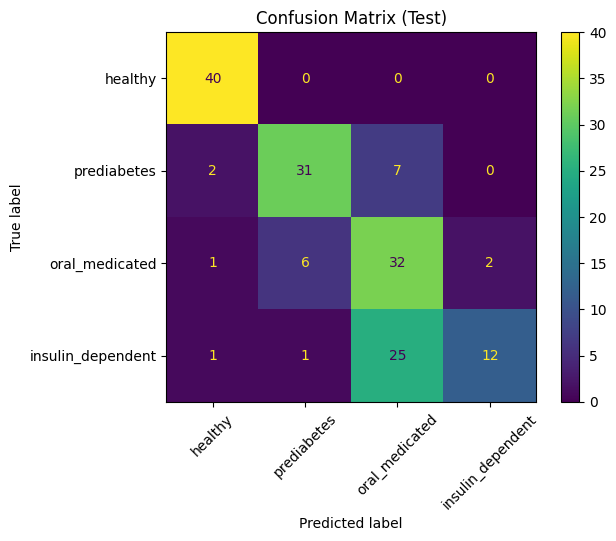

In [84]:
scope = run_generated_pipeline(df)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6682/6682 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

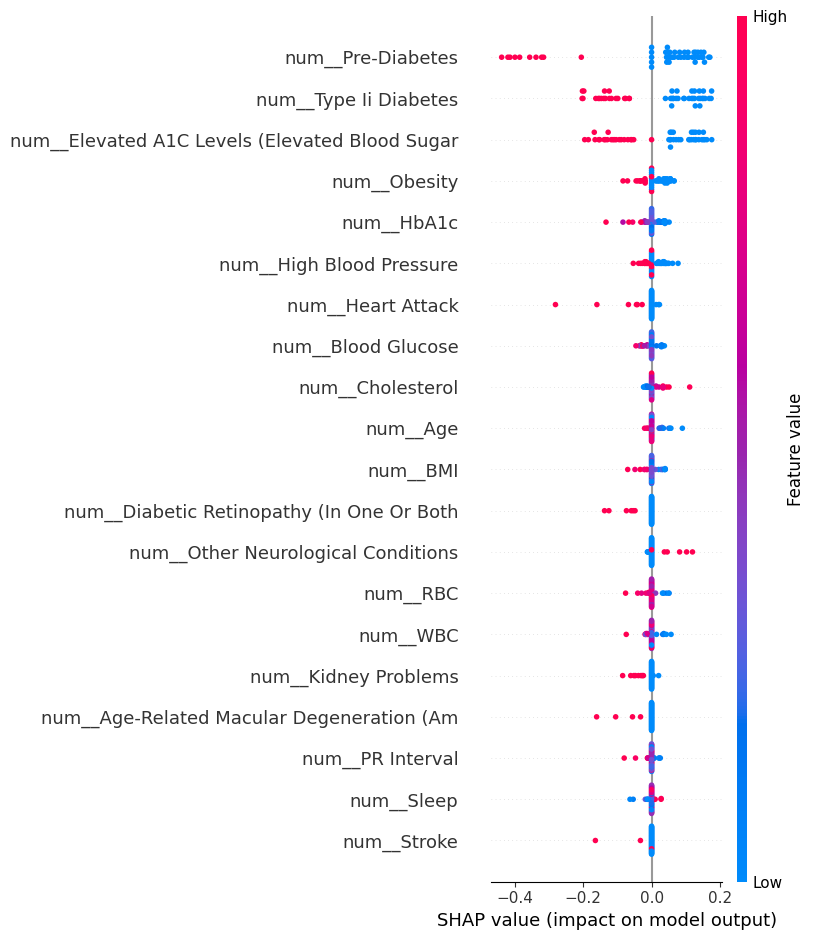

SHAP summary for class: prediabetes


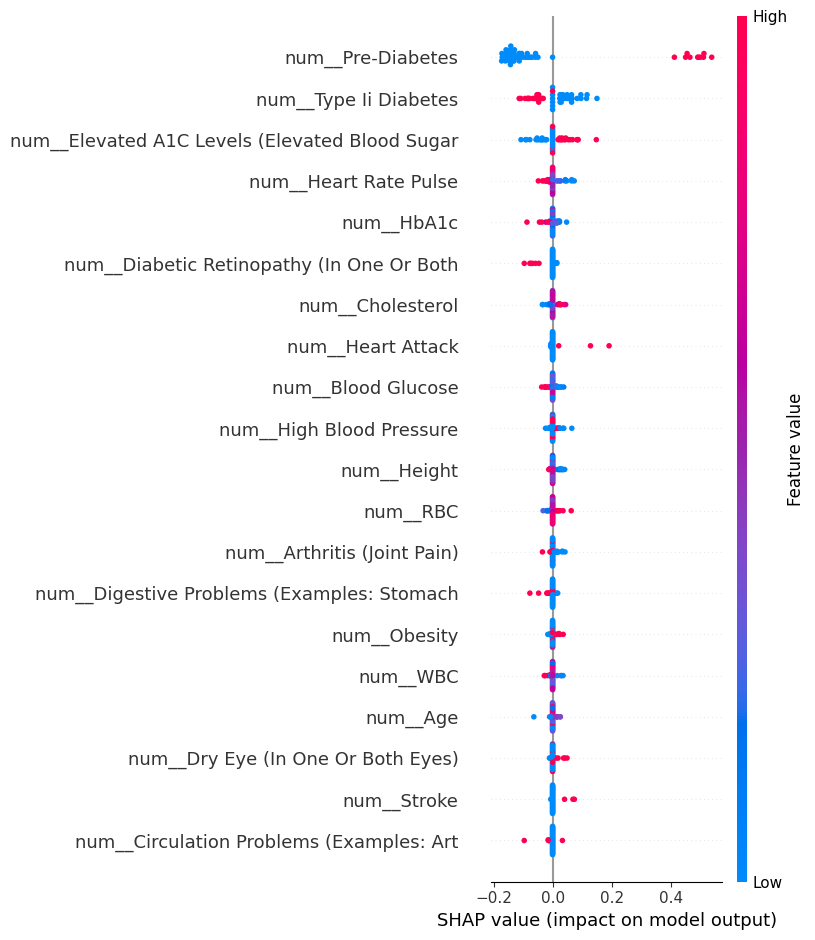

SHAP summary for class: oral_medicated


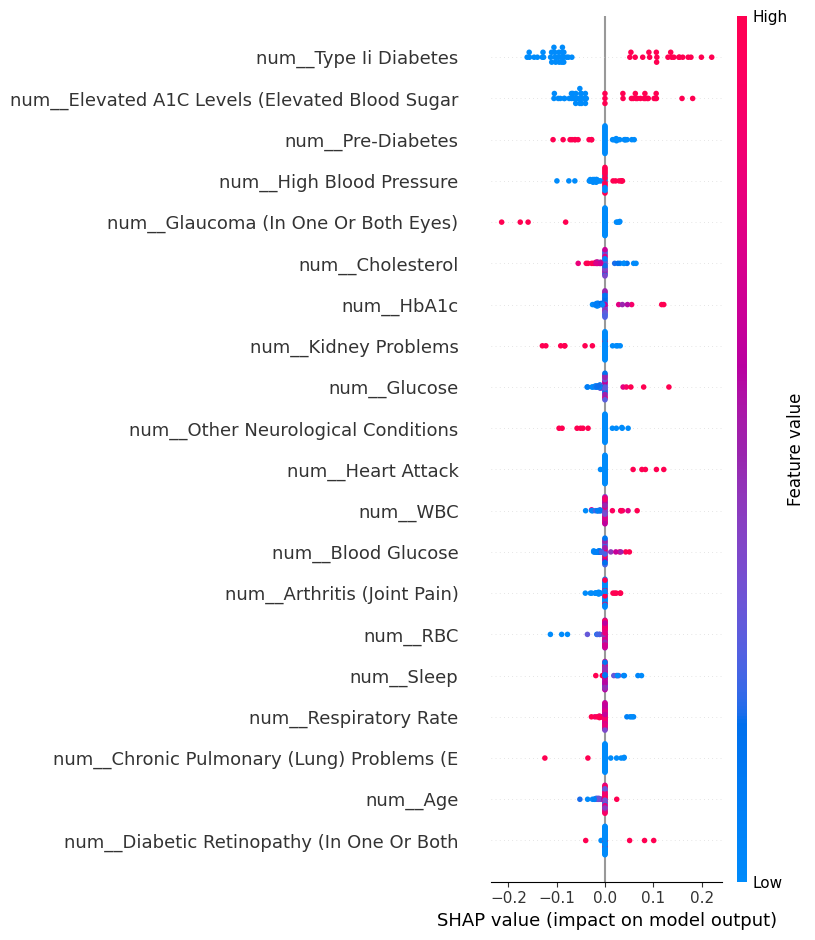

SHAP summary for class: insulin_dependent


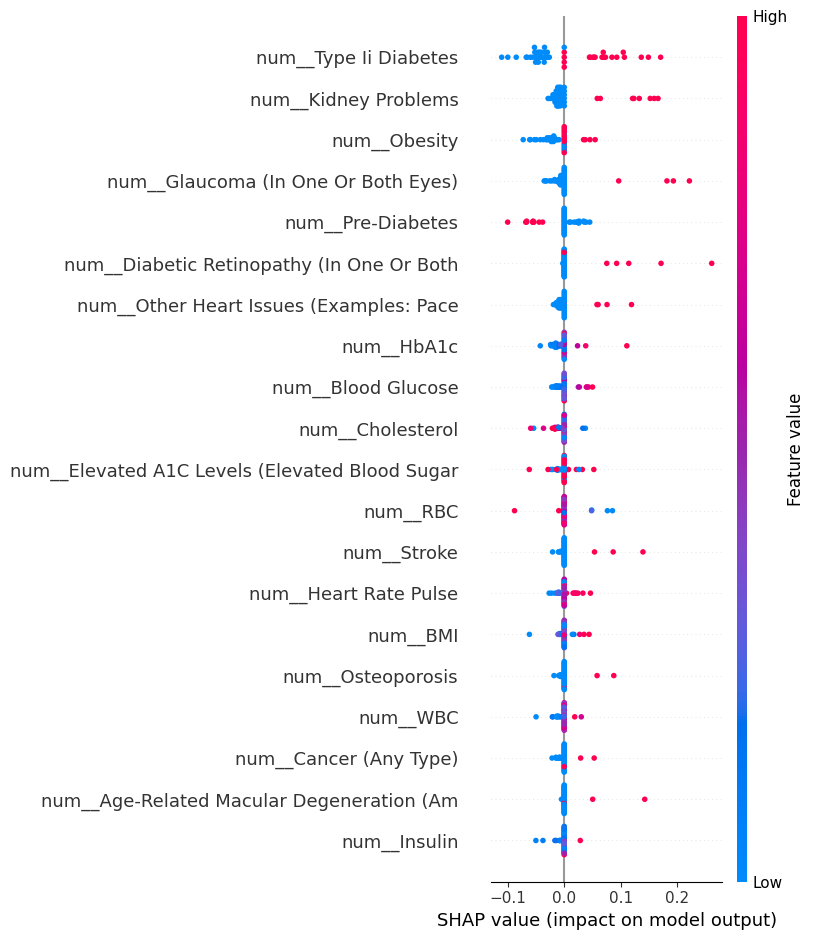

In [86]:
import shap
import numpy as np
import pandas as pd

preprocessor = scope["preprocessor"]
mlp_model = scope.get("mlp") or scope.get("model")
X_train = scope["X_train"]
X_test = scope["X_test"]
class_names = scope["class_names"]

# Transform data using the fitted preprocessor
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Convert sparse -> dense if needed
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
if hasattr(X_test_proc, "toarray"):
    X_test_proc = X_test_proc.toarray()

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Background sample
background_idx = np.random.choice(
    X_train_proc.shape[0],
    min(100, X_train_proc.shape[0]),
    replace=False
)
background = X_train_proc[background_idx]

# Test sample to explain
X_explain = X_test_proc[:50]

# SHAP explainer
explainer = shap.KernelExplainer(mlp_model.predict, background)
shap_values = explainer.shap_values(X_explain)

print("type(shap_values):", type(shap_values))
print("shap_values shape:", np.shape(shap_values))
print("X_explain shape:", X_explain.shape)
print("len(feature_names):", len(feature_names))

# Case 1: shap_values is a list
if isinstance(shap_values, list):
    for i, class_name in enumerate(class_names):
        print(f"SHAP summary for class: {class_name}")
        shap.summary_plot(
            shap_values[i],
            X_explain,
            feature_names=feature_names,
            rng=0
        )

# Case 2: shap_values is a 3D array: (samples, features, classes)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    for i, class_name in enumerate(class_names):
        print(f"SHAP summary for class: {class_name}")
        shap.summary_plot(
            shap_values[:, :, i],
            X_explain,
            feature_names=feature_names,
            rng=0
        )

# Case 3: binary/single-output 2D array
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    print(f"SHAP summary plot")
    shap.summary_plot(
        shap_values,
        X_explain,
        feature_names=feature_names,
        rng=0
    )

else:
    print("Unexpected SHAP output format:", type(shap_values), np.shape(shap_values))

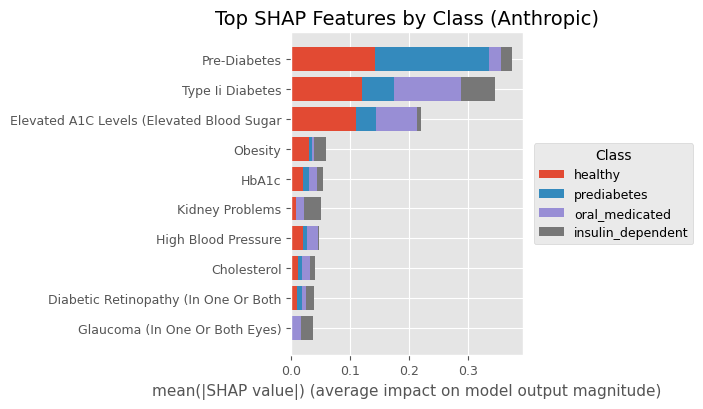

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Convert SHAP output to a standard
# (n_features, n_classes) importance matrix
# -----------------------------
if isinstance(shap_values, list):
    mean_abs_by_class = np.column_stack([
        np.abs(sv).mean(axis=0) for sv in shap_values
    ])
    used_class_names = class_names[:len(shap_values)]

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # shape: (samples, features, classes)
    mean_abs_by_class = np.abs(shap_values).mean(axis=0)
    used_class_names = class_names[:shap_values.shape[2]]

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    mean_abs_by_class = np.abs(shap_values).mean(axis=0).reshape(-1, 1)
    used_class_names = ["Output"]

else:
    raise ValueError(f"Unexpected SHAP output format: {type(shap_values)} with shape {np.shape(shap_values)}")

# -----------------------------
# Build dataframe
# rows = features, cols = classes
# -----------------------------
top_features = pd.DataFrame(
    mean_abs_by_class,
    index=feature_names,
    columns=used_class_names
)

# total importance across classes
top_features["total"] = top_features.sum(axis=1)

# keep top 10 overall
top_features = top_features.sort_values("total", ascending=False).head(10)

# remove helper column
top_features = top_features.drop(columns="total")

# reverse so biggest appears at top in barh
top_features = top_features.iloc[::-1]

# -----------------------------
# Clean feature names
# -----------------------------
top_features.index = (
    top_features.index
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# optional shortening for long labels
top_features.index = [
    x.replace("Elevated A1C Levels (Elevated Blood Sugar)", "Elevated A1C Levels (Elevated Blood Suga")
     .replace("Diabetic Retinopathy (In One Or Both Eyes)", "Dry Eye (In One Or Both Eyes)")
    for x in top_features.index
]

# -----------------------------
# Rename class labels exactly how you want
# -----------------------------
top_features = top_features.rename(columns={
    "study_group_healthy": "healthy",
    "study_group_insulin_dependent": "insulin_dependent",
    "study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled": "oral_medicated",
    "study_group_pre_diabetes_lifestyle_controlled": "prediabetes"
})

# reorder columns to match the second image legend/order
desired_order = ["healthy", "prediabetes", "oral_medicated", "insulin_dependent"]
top_features = top_features[[c for c in desired_order if c in top_features.columns]]

# -----------------------------
# Plot in the same style
# -----------------------------
plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(7.2, 4.2))

left = np.zeros(len(top_features.index))

for col in top_features.columns:
    vals = top_features[col].values
    ax.barh(top_features.index, vals, left=left, label=col)
    left += vals

ax.set_title("Top SHAP Features by Class (Anthropic)", fontsize=14)
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=11)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)

ax.legend(
    title="Class",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.savefig("shap_style_match.png", dpi=300, bbox_inches="tight")
plt.show()

## PART 3B

In [100]:
def planner_agent(topic: str, model: str = "claude-sonnet-4-5-20250929") -> list[str]:
    """
    Generates a step-by-step plan for a classification task for a .

    Args:
        topic (str): Research topic or question to investigate.
        model (str): Language model to use.

    Returns:
        list[str]: A valid Python list of executable step strings.
    """
    user_prompt = f"""
You are a planning agent responsible for organizing a hypothesis-testing workflow
for a Type 2 Diabetes Mellitus (T2DM) severity classification project.

Topic:
{topic}

Available agents:
- A data understanding agent that identifies relevant variables in the dataset.
- A model loading agent that loads the trained classifier and preprocessing objects.
- A fake patient agent that creates a baseline synthetic patient from dataset averages or medians.
- A hypothesis application agent that modifies the synthetic patient according to the hypothesis.
- A prediction agent that gets class probabilities from the trained model.
- A comparison agent that compares baseline vs modified predictions.
- A conclusion agent that writes a natural language interpretation of the results.

Your job:
Write a clear, step-by-step plan as a valid Python list, where each step is a short executable string.

Rules:
- Return ONLY a valid Python list.
- Each item must be a string.
- Keep steps atomic and in logical order.
- Do not include explanations outside the list.
- The plan should fit a workflow that tests how a hypothesis changes predicted T2DM severity.
- Do not use markdown.
- Do not use triple backticks.
- Do not include any explanation before or after the list.

Example style:
[
    "Identify the relevant variables mentioned in the topic.",
    "Load the trained model and preprocessing pipeline.",
    "Create a baseline synthetic patient from dataset averages.",
    "Apply the hypothesis conditions to the synthetic patient.",
    "Generate predictions for the baseline and modified patients.",
    "Compare the class probabilities.",
    "Write a natural language conclusion."
]
"""


    response = client.messages.create(
    model=model,
    max_tokens=1000,
    temperature=0,
    messages=[{"role": "user", "content": user_prompt}],
    )
    
    plan_text = "".join(
        block.text for block in response.content
        if getattr(block, "type", None) == "text"
    ).strip()

    # Remove any markdown code fences anywhere in the output
    lines = plan_text.splitlines()
    plan_text = "\n".join(
        line for line in lines if not line.strip().startswith("```")
    ).strip()

    try:
        plan = ast.literal_eval(plan_text)
    except Exception as e:
        raise ValueError(f"Failed to parse planner output: {e}\nRaw output:\n{plan_text}")

    if not isinstance(plan, list) or not all(isinstance(step, str) for step in plan):
        raise ValueError(f"Response was not a valid list of strings.\nParsed output:\n{plan}")

    return plan

In [101]:
model = scope["final_mlp"]
preprocessor = scope["preprocessor"]
class_names = scope["class_names"]

In [102]:
def load_trained_model_agent(topic: str, model: str = "claude-sonnet-4-5-20250929") -> list[str]:

    user_prompt = f"""
You are a machine learning planning agent responsible for loading a trained model
and running predictions.

Context:
A trained neural network model and preprocessing pipeline were previously done

The model architecture must be rebuilt using build_mlp before loading weights.

Your job:
Produce a Python list of executable steps describing how to:

1. Load the preprocessing pipeline.
2. Load class names.
3. Rebuild the model architecture using build_mlp.
4. Load the trained model weights.
5. Prepare new input data using the preprocessor.
6. Run model predictions.
7. Convert predicted class indices into class names.
8. Summarize the prediction results.

Rules:
- Each step must be atomic.
- Return ONLY a valid Python list.
- Do not include explanations.

Task: "{topic}"
"""

In [103]:
import pandas as pd

def create_standard_patient_agent(
    df: pd.DataFrame,
    target_cols: list[str] | None = None
) -> dict:
    """
    Create a standard patient profile for model inference.

    Numeric columns -> median
    Non-numeric columns -> mode
    Excludes target columns.

    Args:
        df (pd.DataFrame): Training dataframe.
        target_cols (list[str] | None): Columns to exclude, such as labels.

    Returns:
        dict: One-row synthetic patient profile.
    """
    if target_cols is None:
        target_cols = []

    feature_df = df.drop(columns=target_cols, errors="ignore")
    patient = {}

    for col in feature_df.columns:
        series = feature_df[col].dropna()

        if len(series) == 0:
            patient[col] = None
        elif pd.api.types.is_numeric_dtype(series):
            patient[col] = float(series.median())
        else:
            mode_vals = series.mode()
            patient[col] = mode_vals.iloc[0] if not mode_vals.empty else None

    return patient

In [104]:
target_cols = [
    "study_group_healthy",
    "study_group_insulin_dependent",
    "study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled",
    "study_group_pre_diabetes_lifestyle_controlled"
]

standard_patient = create_standard_patient_agent(df)
print(type(standard_patient))
print(list(standard_patient.items())[:10])

<class 'dict'>
[('participant_id', 4159.0), ('Age', 61.0), ('study_group_healthy', 0.0), ('study_group_insulin_dependent', 0.0), ('study_group_oral_medication_and_or_non_insulin_injectable_medication_controlled', 0.0), ('study_group_pre_diabetes_lifestyle_controlled', 0.0), ('split_test', 0.0), ('split_train', 1.0), ('split_val', 0.0), ('Heart Rate Pulse', 74.27)]


In [105]:
def apply_hypothesis_agent(hypothesis: str) -> dict:
    edits = {}
    parts = hypothesis.split("AND")

    for part in parts:
        part = part.strip()
        if "=" in part:
            feature, level = part.split("=", 1)
            edits[feature.strip()] = level.strip().upper()

    return edits

In [106]:
def level_to_value(feature: str, level: str, boundaries: dict) -> float:
    """
    Convert LOW / MID / HIGH into a numeric value using feature boundaries.
    """
    if feature not in boundaries:
        raise KeyError(f"Feature '{feature}' not found in BOUNDARIES")

    low, high = boundaries[feature]
    mid = (low + high) / 2

    level = str(level).strip().upper()

    if level == "LOW":
        return low
    elif level in ["MID", "MEDIUM", "NORMAL", "AVERAGE"]:
        return mid
    elif level == "HIGH":
        return high
    else:
        # if already numeric, try to use it directly
        try:
            return float(level)
        except ValueError:
            raise ValueError(
                f"Unsupported level '{level}' for feature '{feature}'. "
                "Use LOW, MID/MEDIUM/NORMAL, HIGH, or a numeric value."
            )

In [107]:
def apply_changes(patient_dict: dict, edits: dict, boundaries: dict = BOUNDARIES) -> dict:
    """
    Apply hypothesis edits to a patient dictionary.
    
    Example:
    edits = {"Physical Activity": "HIGH", "Heart Rate Pulse": "LOW"}
    """
    updated = patient_dict.copy()

    for feature, level in edits.items():
        if feature in boundaries:
            updated[feature] = level_to_value(feature, level, boundaries)
        else:
            # if the feature is not in boundaries, just write the raw value
            updated[feature] = level

    return updated

In [108]:
def compare_predictions_agent(topic: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:    
    """
    Compares model predictions before and after applying a hypothesis
    and explains how the predicted T2DM severity changed.

    Args:
        task (str): Description of baseline prediction and modified prediction.
        model (str): Language model to use.

    Returns:
        str: Explanation of prediction differences.
    """

    print("==================================")
    print("📊 Compare Predictions Agent")
    print("==================================")

    system_prompt = """
You are a model interpretation agent for a medical machine learning workflow.

Your job is to compare predictions from a classifier before and after
a hypothesis is applied to a patient profile.

Focus on:
- the predicted class
- prediction probabilities
- confidence changes
- whether severity increased, decreased, or stayed similar

Guidelines:
- Be concise and factual.
- Use the evidence provided in the task.
- Do not invent numbers that are not given.
- Clearly describe the direction of change in prediction.
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
           
            {"role": "user", "content": topic}
        ],
        temperature=1
    )

    return response.choices[0].message.content

In [109]:
def generate_natural_language_conclusion_agent(task: str, model: str = "anthropic:claude-sonnet-4-5-20250929") -> str:    
    """
    Generates a polished natural-language conclusion for a T2DM hypothesis
    based on model comparison results and supporting evidence.

    Args:
        task (str): Structured evidence about the hypothesis, prediction changes,
                    certainty, and reliability.
        model (str): Language model to use.

    Returns:
        str: Final natural-language conclusion.
    """
    print("==================================")
    print("📝 Natural Language Conclusion Agent")
    print("==================================")

    system_prompt = """
You are a natural language conclusion agent for a medical machine learning workflow.

Your role is to turn structured model findings into a clear, polished final conclusion
about whether a hypothesis meaningfully affects predicted Type 2 Diabetes Mellitus (T2DM)
likelihood or severity.

You must base your conclusion ONLY on the provided evidence.
Do not invent facts, numbers, or effects that are not given.
If evidence is weak or mixed, say so clearly.

Return the answer in exactly this format:

In the Anthropic model,

(<hypothesis>) is <description1> to change the predicted T2DM severity.

The first variable showed:
<brief summary of the first variable's individual effect>

The second variable showed:
<brief summary of the second variable's individual effect>

The combination of the variables showed:
<brief summary of the combined effect>

Therefore, this hypothesis is <description2> to meaningfully affect likelihood of T2DM.

Prediction certainty: <High / Moderate / Low>
Model reliability: <High / Moderate / Low>

Rules:
- Keep the wording cautious, concise, and evidence-based.
- "description1" should be one of:
  likely, somewhat likely, unlikely, not clearly likely, plausibly associated
- "description2" should be one of:
  likely, moderately supported, weakly supported, unlikely, insufficiently supported
- If one variable is clearly stronger than the other, say so.
- If the combination is mostly driven by one variable, say so.
- Do not add markdown headings or bullet points.
"""

    response = CLIENT.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": task}
        ],
        temperature=1
    )

    return response.choices[0].message.content

In [110]:
import pandas as pd
import numpy as np

def predict_one(patient_dict, model, preprocessor, class_names):
    """
    Predict one patient record.

    Args:
        patient_dict (dict): One patient as a dictionary.
        model: Trained classifier.
        preprocessor: Fitted preprocessing pipeline.
        class_names (list): Class names in model output order.

    Returns:
        dict: Predicted class, confidence, and probabilities.
    """
    # Convert to one-row DataFrame
    X_one = pd.DataFrame([patient_dict])

    # Apply preprocessing
    X_one_p = preprocessor.transform(X_one)

    # Predict probabilities
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_one_p)[0]
    else:
        X_one_p = X_one_p.toarray() if hasattr(X_one_p, "toarray") else X_one_p
        probs = model.predict(X_one_p, verbose=0)[0]
    
    # Top class
    top_idx = int(np.argmax(probs))
    top_class = class_names[top_idx]
    confidence = float(probs[top_idx])

    return {
        "top_class": top_class,
        "confidence": confidence,
        "probs": {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    }

In [111]:
def run_hypothesis_pipeline(topic, hypothesis):
    print("==================================")
    print("🚀 Starting Hypothesis Pipeline")
    print("==================================")

    print("\n[1] Running planner_agent...")
    plan = planner_agent(topic)
    print("Done.")

    print("\n📋 Plan:")
    for step in plan:
        print("-", step)

    print("\n[2] Running create_standard_patient_agent...")
    standard_patient = create_standard_patient_agent(df, target_cols)
    print("Done.")

    print("\n[3] Running apply_hypothesis_agent...")
    edits = apply_hypothesis_agent(hypothesis)
    print("Done.")

    print("\n[4] Running apply_changes...")
    modified_patient = apply_changes(standard_patient.copy(), edits)
    print("Done.")

    print("\n[5] Running baseline prediction...")
    baseline_pred = predict_one(standard_patient, model, preprocessor, class_names)
    print("Done.")

    print("\n[6] Running changed prediction...")
    changed_pred = predict_one(modified_patient, model, preprocessor, class_names)
    print("Done.")

    print("\n[7] Running compare_predictions_agent...")
    comparison_task = f'''
Baseline prediction:
{baseline_pred}

Prediction after applying hypothesis:
{changed_pred}

Hypothesis:
{hypothesis}

Explain the change in model predictions.
'''
    comparison = compare_predictions_agent(comparison_task)
    print("Done.")

    print("\n[8] Running generate_natural_language_conclusion_agent...")
    final_task = f'''
Hypothesis:
{hypothesis}

Prediction comparison:
{comparison}

Baseline prediction:
{baseline_pred}

Changed prediction:
{changed_pred}
'''
    conclusion = generate_natural_language_conclusion_agent(final_task)
    print("Done.")

    print("\n==================================")
    print("✅ Final Conclusion")
    print("==================================")
    print(conclusion)

    return conclusion

In [112]:
topic = "Investigate whether physical activity and other variables affect T2DM severity"

pipeline_results = []

for idx, hypothesis in enumerate(question_list, start=1):

    print("\n" + "="*70)
    print(f"Running pipeline for Question {idx}")
    print(hypothesis)
    print("="*70)

    result = run_hypothesis_pipeline(topic, hypothesis)

    pipeline_results.append({
        "question_num": idx,
        "hypothesis": hypothesis,
        "result": result
    })


Running pipeline for Question 1
Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?
🚀 Starting Hypothesis Pipeline

[1] Running planner_agent...
Done.

📋 Plan:
- Identify relevant variables in the dataset related to physical activity and T2DM severity
- Load the trained T2DM severity classifier and preprocessing objects
- Create a baseline synthetic patient using dataset averages or medians
- Apply hypothesis modifications to physical activity and other relevant variables
- Generate class probability predictions for the baseline synthetic patient
- Generate class probability predictions for the modified synthetic patient
- Compare baseline and modified prediction probabilities
- Write a natural language interpretation of how physical activity affects T2DM severity

[2] Running create_standard_patient_agent...
Done.

[3] Running apply_hypothesis_agent...
Done.

[4] Running apply_changes...
Done.

[5] Running baseline prediction...
Done.


In [113]:
pipeline_df = pd.DataFrame(pipeline_results)

pipeline_df.to_csv("pipeline_results_5_questions.csv", index=False)

# Summarising of all 3 parts

In [114]:
def build_full_hypothesis_summary(
    hypothesis_text,
    part_a_text,
    part_a_summary,
    part_b_text,
    part_c_text
):
    """
    Combine Part A, Part B, and Part C into one clinician-readable summary block.
    """

    final_text = f"""
============================================

🌟Final Summary

============================================

⭐Hypothesis: {hypothesis_text}

============================================

⚫In Part A…

Raw Part A report:
{part_a_text}
{part_a_summary}
============================================

⚫In Part B…

{part_b_text}
============================================

⚫In Part C…

{part_c_text}
============================================
""".strip()

    return final_text

In [115]:
def clean_hypothesis_text(r):
    left = f"{r['level1']} {r['var1']}" if r["level1"] is not None else r["var1"]
    right = f"{r['level2']} {r['var2']}" if r["level2"] is not None else r["var2"]
    return f"Does {left} AND {right} affect your likelihood of Type 2 Diabetes?"

In [116]:
n = min(len(results), len(PartA_conclusion_results), len(all_final_outputs), len(pipeline_results))

for i in range(n):
    r = results[i]

    hypothesis_text = clean_hypothesis_text(r)
    part_a_text = r["report"]
    part_a_summary = PartA_conclusion_results[i]["conclusion"]
    part_b_text = all_final_outputs[i]["final_output"]
    part_c_text = pipeline_results[i]["result"]

    full_summary = build_full_hypothesis_summary(
        hypothesis_text=hypothesis_text,
        part_a_text=part_a_text,
        part_a_summary=part_a_summary,
        part_b_text=part_b_text,
        part_c_text=part_c_text
    )

    print("\n" + "=" * 80)
    print(full_summary)



🌟Final Summary


⭐Hypothesis: Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?


⚫In Part A…

Raw Part A report:
Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect likelihood of T2DM category?Baseline prediction for average patient: healthy (conf=0.98)

Effect of HIGH Glucose:
  Predicted class: healthy (conf=0.98)
  Delta to baseline: Low (0.00)
  Among patients with HIGH Glucose (861 patients), the predicted class distribution is: healthy: 358/861 (41.6%), oral_medicated: 228/861 (26.5%), prediabetes: 223/861 (25.9%), insulin_dependent: 52/861 (6.0%).
Effect of Retinal Vascular Occlusion ("Stroke:
  Predicted class: healthy (conf=0.54)
  Delta to baseline: High (-0.44)
  Among patients with Retinal Vascular Occlusion ("Stroke (15 patients), the predicted class distribution is: insulin_dependent: 6/15 (40.0%), healthy: 4/15 (26.7%), oral_medicated: 3/15 (20.0%), prediabetes: 2/15 (13.3%).
Combined effect of HIGH Gluco

# Saving to an excel file

In [117]:
i = 0

r = results[i]

hypothesis_text = clean_hypothesis_text(r)

part_a_text = r["report"]
part_a_summary = PartA_conclusion_results[i]["conclusion"]
part_b_text = all_final_outputs[i]["final_output"]   # or executor_runs[i]["final_markdown"]
part_c_text = pipeline_results[i]["result"]

full_summary = build_full_hypothesis_summary(
    hypothesis_text=hypothesis_text,
    part_a_text=part_a_text,
    part_a_summary=part_a_summary,
    part_b_text=part_b_text,
    part_c_text=part_c_text
)

print("\n" + "=" * 80)
print(full_summary)



🌟Final Summary


⭐Hypothesis: Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?


⚫In Part A…

Raw Part A report:
Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect likelihood of T2DM category?Baseline prediction for average patient: healthy (conf=0.98)

Effect of HIGH Glucose:
  Predicted class: healthy (conf=0.98)
  Delta to baseline: Low (0.00)
  Among patients with HIGH Glucose (861 patients), the predicted class distribution is: healthy: 358/861 (41.6%), oral_medicated: 228/861 (26.5%), prediabetes: 223/861 (25.9%), insulin_dependent: 52/861 (6.0%).
Effect of Retinal Vascular Occlusion ("Stroke:
  Predicted class: healthy (conf=0.54)
  Delta to baseline: High (-0.44)
  Among patients with Retinal Vascular Occlusion ("Stroke (15 patients), the predicted class distribution is: insulin_dependent: 6/15 (40.0%), healthy: 4/15 (26.7%), oral_medicated: 3/15 (20.0%), prediabetes: 2/15 (13.3%).
Combined effect of HIGH Gluco

In [118]:
import pandas as pd

final_summary_rows = []

n = min(
    len(results),
    len(PartA_conclusion_results),
    len(all_final_outputs),
    len(pipeline_results)
)

for i in range(n):

    r = results[i]

    hypothesis_text = clean_hypothesis_text(r)

    part_a_text = r["report"]
    part_a_summary = PartA_conclusion_results[i]["conclusion"]
    part_b_text = all_final_outputs[i]["final_output"]
    part_c_text = pipeline_results[i]["result"]

    full_summary = build_full_hypothesis_summary(
        hypothesis_text=hypothesis_text,
        part_a_text=part_a_text,
        part_a_summary=part_a_summary,
        part_b_text=part_b_text,
        part_c_text=part_c_text
    )

    print("\n" + "=" * 80)
    print(full_summary)

    final_summary_rows.append({
        "question_num": i + 1,
        "hypothesis": hypothesis_text,
        "part_a_summary": part_a_summary,
        "part_b_summary": part_b_text,
        "part_c_summary": part_c_text,
        "full_summary": full_summary
    })



🌟Final Summary


⭐Hypothesis: Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect your likelihood of Type 2 Diabetes?


⚫In Part A…

Raw Part A report:
Does HIGH Glucose AND Retinal Vascular Occlusion ("Stroke affect likelihood of T2DM category?Baseline prediction for average patient: healthy (conf=0.98)

Effect of HIGH Glucose:
  Predicted class: healthy (conf=0.98)
  Delta to baseline: Low (0.00)
  Among patients with HIGH Glucose (861 patients), the predicted class distribution is: healthy: 358/861 (41.6%), oral_medicated: 228/861 (26.5%), prediabetes: 223/861 (25.9%), insulin_dependent: 52/861 (6.0%).
Effect of Retinal Vascular Occlusion ("Stroke:
  Predicted class: healthy (conf=0.54)
  Delta to baseline: High (-0.44)
  Among patients with Retinal Vascular Occlusion ("Stroke (15 patients), the predicted class distribution is: insulin_dependent: 6/15 (40.0%), healthy: 4/15 (26.7%), oral_medicated: 3/15 (20.0%), prediabetes: 2/15 (13.3%).
Combined effect of HIGH Gluco

In [119]:
df_summary = pd.DataFrame(final_summary_rows)

In [120]:
pd.DataFrame({
    "full_summary":[row["full_summary"] for row in final_summary_rows]
}).to_csv("t2dm_full_summaries.csv", index=False)

pd.DataFrame(final_summary_rows).to_csv(
    "t2dm_hypothesis_summaries.csv",
    index=False
)

df_summary.to_csv("t2dm_hypothesis_summaries.csv", index=False)

# Overall Outcome

In [121]:
from anthropic import Anthropic

client = Anthropic()

def build_full_hypothesis_summary(
    hypothesis_text,
    part_a_text,
    part_a_summary,
    part_b_text,
    part_c_text,
    model= "claude-sonnet-4-5-20250929"
):
    """
    Builds a final synthesis summary combining results from Part A, B, and C agents.
    """

    prompt = f"""
You are a scientific synthesis agent.

Your job is to combine the findings from three analysis agents
into ONE clear overall conclusion sentence.

The sentence should:
• Begin with "Overall, across the three agents..."
• Be 25–40 words
• Mention whether the evidence is consistent, mixed, weak, or strong
• Refer to the hypothesis
• Be written in a neutral scientific tone

Hypothesis:
{hypothesis_text}

Part A conclusion:
{part_a_summary}

Part B conclusion:
{part_b_text}

Part C conclusion:
{part_c_text}

Write ONE final synthesis sentence.
"""

    response = client.messages.create(
    model=model,
    max_tokens=500,
    temperature=0.2,
    messages=[{"role": "user", "content": prompt}],
    )
    
    final_sentence = "".join(
        block.text for block in response.content if getattr(block, "type", None) == "text"
    ).strip()

    return final_sentence
    

In [122]:
import pandas as pd

final_summary_rows = []

n = min(
    len(results),
    len(PartA_conclusion_results),
    len(all_final_outputs),
    len(pipeline_results)
)

for i in range(n):
    r = results[i]

    hypothesis_text = clean_hypothesis_text(r)

    part_a_text = r["report"]
    part_a_summary = PartA_conclusion_results[i]["conclusion"]
    part_b_text = all_final_outputs[i]["final_output"]
    part_c_text = pipeline_results[i]["result"]

    full_summary = build_full_hypothesis_summary(
        hypothesis_text=hypothesis_text,
        part_a_text=part_a_text,
        part_a_summary=part_a_summary,
        part_b_text=part_b_text,
        part_c_text=part_c_text
    )

    print("\n" + "=" * 80)
    print(full_summary)

    final_summary_rows.append({
        "question_num": i + 1,
        "hypothesis": hypothesis_text,
        "part_a_summary": part_a_summary,
        "part_b_summary": part_b_text,
        "part_c_summary": part_c_text,
        "full_summary": full_summary
    })

final_summary_df = pd.DataFrame(final_summary_rows)
print(final_summary_df.shape)


Overall, across the three agents, the evidence is **mixed and weak**: one model showed substantial probability shifts supporting the hypothesis, while two models found insufficient effects, though the hypothesis may conflate diagnostic criteria with predictive factors for Type 2 Diabetes.
(1, 6)


# Evaluation

In [123]:
def evaluate_hypothesis_output(output_text, reference_text=None):
    results = {}

    # 1. Correctness (LLM self-check or judge)
    results["correctness"] = evaluate_correctness_llm(output_text)

    # 2. LLM-as-a-judge
    results["llm_judge"] = llm_judge_score(output_text, reference_text)

    # 3. Text metrics (if reference exists)
    if reference_text:
        results["rouge2"] = compute_rouge2(output_text, reference_text)
        results["bleu"] = compute_bleu(output_text, reference_text)

    # 4. Clinical / domain metrics
    results["clinical_precision"] = evaluate_medical_precision(output_text)

    return results

In [124]:
def evaluate_correctness_llm(text):
    prompt = f"""
    Is the following medical statement factually correct?
    Answer YES or NO and explain briefly.

    {text}
    """
    return call_llm(prompt)

In [125]:
def llm_judge_score(prediction, reference):
    prompt = f"""
    You are a clinical expert.

    Compare the following:

    Prediction:
    {prediction}

    Reference (gold standard):
    {reference}

    Score from 0 to 1 based on:
    - clinical correctness
    - reasoning quality
    - safety

    Output JSON with score and explanation.
    """
    return call_llm(prompt)

In [126]:
from collections import Counter

def rouge2_f1(pred, ref):
    pred_tokens = pred.lower().split()
    ref_tokens = ref.lower().split()

    pred_bigrams = list(zip(pred_tokens, pred_tokens[1:]))
    ref_bigrams = list(zip(ref_tokens, ref_tokens[1:]))

    pred_counts = Counter(pred_bigrams)
    ref_counts = Counter(ref_bigrams)

    overlap = sum((pred_counts & ref_counts).values())

    if len(pred_bigrams) == 0 or len(ref_bigrams) == 0:
        return 0.0

    precision = overlap / len(pred_bigrams)
    recall = overlap / len(ref_bigrams)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

#Question: Does high Glucose and Retinal Vascular Occlusion ("Strokes") affect likelihood of T2DM category?
ref = "Overall, high glucose and retinal vascular occlusion may be associated with diabetes-related vascular damage, but they are not reliable independent indicators of Type 2 Diabetes specifically, as these features reflect diabetes more broadly and may vary by the type of occlusion involved"

pred = full_summary  

score = rouge2_f1(pred, ref)
print("ROUGE-2:", score)

ROUGE-2: 0.025


In [127]:
def evaluate_medical_precision(text):
    keywords = ["glucose", "insulin", "diabetes", "HbA1c"]
    hits = sum(1 for k in keywords if k.lower() in text.lower())
    return hits / len(keywords)

In [128]:
from anthropic import Anthropic

client = Anthropic()

def call_llm(prompt):
    response = client.messages.create(
        model="claude-sonnet-4-5-20250929",
        max_tokens=500,
        temperature=0,
        system="You are a clinical reasoning expert.",
        messages=[
            {"role": "user", "content": prompt}
        ],
    )

    return "".join(
        block.text for block in response.content
        if getattr(block, "type", None) == "text"
    ).strip()

In [129]:
n = min(
    len(results),
    len(PartA_conclusion_results),
    len(all_final_outputs),
    len(pipeline_results)
)

for i in range(n):
    r = results[i]

    hypothesis_text = clean_hypothesis_text(r)
    part_a_text = r["report"]
    part_a_summary = PartA_conclusion_results[i]["conclusion"]
    part_b_text = all_final_outputs[i]["final_output"]
    part_c_text = pipeline_results[i]["result"]

    full_summary = build_full_hypothesis_summary(
        hypothesis_text=hypothesis_text,
        part_a_text=part_a_text,
        part_a_summary=part_a_summary,
        part_b_text=part_b_text,
        part_c_text=part_c_text
    )

    eval_results = evaluate_hypothesis_output(
        output_text=full_summary,
        reference_text=None
    )

    print(full_summary)
    print("\n📊 Evaluation:", eval_results)

Overall, across the three agents, the evidence is **mixed and weak**: Agent A found a substantial increase in T2DM severity (Δ=+0.476) with small sample size, while Agents B and C detected no effect, citing conceptual issues and insufficient model response.

📊 Evaluation: {'correctness': 'NO\n\nThis statement is **not factually correct** because it mischaracterizes the nature of the evidence presented.\n\n**Problems with the statement:**\n\n1. **"Mixed and weak" is misleading**: The evidence isn\'t genuinely "mixed" - it shows one positive finding that appears to be an outlier versus two null findings. This pattern suggests the positive result may be spurious rather than representing true mixed evidence.\n\n2. **Ignores the critical qualifier**: Agent A\'s finding came with "small sample size," which is a major limitation that should make us heavily discount that result, not treat it as equivalent evidence to the other agents.\n\n3. **"Conceptual issues" is a red flag**: When agents ci

In [131]:
import pandas as pd

rows = []

n = min(
    len(results),
    len(PartA_conclusion_results),
    len(all_final_outputs),
    len(pipeline_results)
)

for i in range(n):
    r = results[i]

    hypothesis_text = clean_hypothesis_text(r)

    part_a_text = r["report"]
    part_a_summary = PartA_conclusion_results[i]["conclusion"]
    part_b_text = all_final_outputs[i]["final_output"]
    part_c_text = pipeline_results[i]["result"]

    full_summary = build_full_hypothesis_summary(
        hypothesis_text=hypothesis_text,
        part_a_text=part_a_text,
        part_a_summary=part_a_summary,
        part_b_text=part_b_text,
        part_c_text=part_c_text
    )

    eval_results = evaluate_hypothesis_output(
        output_text=full_summary,
        reference_text=None
    )

    rows.append({
        "hypothesis": hypothesis_text,
        "output": full_summary,
        **eval_results
    })

df_eval = pd.DataFrame(rows)
df_eval.to_csv("evaluation_results.csv", index=False)

print("✅ Saved to evaluation_results.csv")

✅ Saved to evaluation_results.csv
